
# **Machine Learning Classification of Supernova Neutrinos in Noisy Detector Environments**
### By Datrim Wadhawan


## Contents
1. [Introduction](#introduction)
2. [Theory](#theory)
3. [Investigating the Data](#investigating-the-data)
4. [Functions for Main Task](#functions-for-main-task)
5. [Building Initial Classifiers](#building-initial-classifiers)
6. [Task 1: Generating Electronic Noise](#task-1-generating-electronic-noise)
7. [Task 2: Overlaying Noise onto Real Events and Testing](#task-2-overlaying-noise-onto-real-events-and-testing)
8. [Task 3: Performance Evaluation](#task-3-performance-evaluation)
9. [Extension 1: Inception CNN Model](#extension-1-inception-cnn-model)
10. [Extension 2: Residual CNN Model](#extension-2-residual-cnn-model)
11. [Extension 3: Simulating Radioactive Gaussian Blobs ](#extension-3-simulating-radioactive-gaussian-blobs)
12. [Overall Conclusion](#overall-conclusion)
13. [References](#references)

In [ ]:
# Import necessary libraries for data manipulation, visualization, and machine learning
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
import random
import seaborn as sns

# Import metrics and models from scikit-learn
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import roc_curve, roc_auc_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

# Import Keras for building neural network models
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential

# Set default colormap for images to 'plasma' for better visibility
plt.rcParams['image.cmap'] = 'plasma'

# Set random seeds for reproducibility across numpy, tensorflow, and random
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)



## Introduction 

The aim of this notebook is to apply machine learning techniques to classify supernova neutrino events. The data is inspired by liquid-argon detectors sued in modern neutrino experiments such as MicroBooNe [[1]](#ref1) and DUNE [[2]](#ref2). I hope to be able to distinguish genuine neutrino interactions from background or noise events, which is a problem motivated by supernova neutrino interactions and could provide us with early warning signals for astrophyscial events. Mutliple models (e.g. CNN-based architectures) are trained and compared to evaluate classification performance in order to investiagte how detector noise and additional background affect model accuracy and reliability. The workflow includes dataset construction, model training, evaluation and performance analysis.

## Theory

#### 1. Supernova Neutrinos and Motivation 
When stars reach the end of their lifetime if they have sufficient mass they explode violently, these explosions are called supernovas. They produce intense bursts of bright light for example SN 1987A [[3]](#ref3), a type II supernova was visible in the sky for serval months in 1987. They also produce neutrinos, that we aim to detect and classify. Due to their low interaction probability, neutrinos can escape the exploding star more easily than light can, this means we can detect them 2-3 hours earlier (in the case of SN 1987A) before we see the light from the supernova. Hence this demonstrates the potential for neutrino-based early warning systems, which is what SNEWS [[4]](#ref4) is trying to accomplish.

#### 2. Neutrino Interactions
Neutrinos are fundamental fermions belonging to the lepton family, they are electrically neutral and interact only via the weak interaction. They have extremely small masses and interact only via the weak force, resulting in a very small interaction cross-section. This makes them highly penetrating particles with a low interaction probability and along with their neutral charge,they are invisible to particle detectors. They come in three neutrino flavours each assicated with a charged lepton: νe ​(electron neutrino), νμ ​(muon neutrino), ντ ​(tau neutrino) with their corresponding anti-particles: $\bar{\nu}e$, $\bar{\nu}\mu$, $\bar{\nu}_\tau$. Their weak interactions can be split into two categories: Charge-Current (CC) Interactions and Neutral-Current (NC) Interactions. 
In CC interactions the neutrino converts into its corresponding charged lepton, this interaction is mediated by the W± boson and produces a visible charged particle that we detect. For example:
$$ \nu_e + n \rightarrow e^{-} + p $$
Where a neutron is converted into a proton to conserve charge and the outgoing electron produces a clear track in the detector.
In NC interactions the neutrino does not change flavour and is mediated by the Z0 boson. This makes detection more difficult, as no charged lepton is produced and only recoil signals or secondary particles may be observed. For example:
$$ \nu + N \rightarrow \nu + N $$
Where the neutrino scatters off a nucleon N and only secondary particles or recoil signals may be observed.

#### 3. Liquid Argon Detectors (Experimental Context)
As previously mentioned, modern experiments such as MicroBooNE [[1]](#ref1) and DUNE [[2]](#ref2) use liquid-argon time-projection chambers (LArTPCs). The working principle is that incident charged particles ionise argon atoms, the freed electrons drift under an electric field and the signals produced by these driftrs are collected on a detection plane to reconstruct particle tracks. These detectors provide high-resolution images of interactions, forming the basis of the dataset used in this project.Supernova neutrinos have energies in the few MeV range, much lower than accelerator neutrinos, which results in faint signals, fewer activated pixels and greater difficulty distinguishing signal from noise.

#### 4. Machine Learning Classification Problem
The task is therefore to classify: signals, from the neutrino interaction images, background, from the noise or non-event images, and to evaluate performance using matrics such as; accuracy, false positive rate (purity) and false negative rate (efficiency)[[7]](#ref7). We do this by simulating electronics noise across the full detector image to mimic real detector conditions in hopes to see how the classifiers perform as noise increases. Also Radioactive backgrounds (e.g. beta decays) can be modelled as Gaussian energy deposits and tested for (as an extension). Along side that as another extension energy reconstruction aims to reconstruct the neutrino energy, and determine the resolution.


## Investigating the Data


The data for this mini-project comes in the form of the following files:

| File | Description |
| ----------- | ----------- |
| larImages.npy | A numpy array of 10,000 100x100 pixel images |
| meta.npy | The meta information about the particles in the image |


The images show the energy deposited in the liquid argon detector in a small slice of space and time. The meta information contains the following 64 numbers  for each image. The PDG Code [[5]](#ref5) is a number which identifies the particle type (e.g electron=11, electron-neutrino=12, etc.)

| Column | Description |
| ----------- | ----------- |
| 0 | Row number |
| 1 | Neutrino Energy (MeV) |
| 2 | Initial state particles (always 2) |
| 3 | Final state particles (varies) |
| 4-8 | Initial Particle 1: PDG code, Total Energy (MeV), $p_x$, $p_y$, $p_z$ | 
| 9-13 | Initial Particle 2: PDG code, Total Energy (MeV), $p_x$, $p_y$, $p_z$ |
| 14-18 | Final Particle 1: PDG code, Total Energy (MeV), $p_x$, $p_y$, $p_z$ | 
| 19-23 | Final Particle 2: PDG code, Total Energy (MeV), $p_x$, $p_y$, $p_z$ |
| $\vdots$ | Final Particle N: PDG code, Total Energy (MeV), $p_x$, $p_y$, $p_z$ |
| 59-63 | Final Particle 10: PDG code, Total Energy (MeV), $p_x$, $p_y$, $p_z$ |

In [2]:
images=np.load('larImages.npy')         # Load the larImages.npy file into a variable called images
meta=np.load('meta.npy')                # Load the meta.npy file into a variable called meta

# Print the shapes of the images and meta arrays to understand their dimensions
print("images.shape",images.shape)
print("meta.shape",meta.shape)

images.shape (10000, 100, 100)
meta.shape (10000, 64)


This section loads the simulated LArTPC images and associated metadata used throughout the project. For the main classification task, only the image data are used, while the metadata are mainly reserved for interpretation and extensions.

Row 0 corresponds to a neutrino of 21.2005 MeV and produced 6 final state particles
Row 1 corresponds to a neutrino of 21.8617 MeV and produced 3 final state particles
Row 2 corresponds to a neutrino of 17.6584 MeV and produced 4 final state particles
Row 3 corresponds to a neutrino of 20.1423 MeV and produced 5 final state particles
Row 4 corresponds to a neutrino of 23.3148 MeV and produced 5 final state particles
Row 5 corresponds to a neutrino of 26.357 MeV and produced 6 final state particles
Row 6 corresponds to a neutrino of 25.075 MeV and produced 5 final state particles
Row 7 corresponds to a neutrino of 14.2213 MeV and produced 5 final state particles
Row 8 corresponds to a neutrino of 20.3488 MeV and produced 5 final state particles
Row 9 corresponds to a neutrino of 15.3484 MeV and produced 7 final state particles


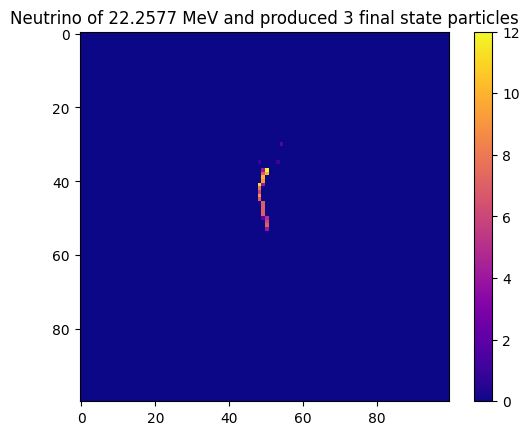

In [ ]:
def reaction(num):
    '''
    Prints basic information about a neutrino interaction from the metadata.

    Inputs
    - num : index of the event in the metadata array

    Outputs
    - None (prints information to console)
    '''
    print("Row",int(meta[num][0]),"corresponds to a neutrino of",meta[num][1], "MeV and produced",int(meta[num][3]),"final state particles")
for i in range(10):
    reaction(i)


firstimg=27
plt.figure()
plt.imshow(images[firstimg])
plt.colorbar()
plt.title(f'Neutrino of {meta[firstimg][1]} MeV and produced {int(meta[firstimg][3])} final state particles')
plt.show()

We first inspect representative neutrino images to understand the visual structure of the signal. Supernova neutrino events are sparse and localised, so visual inspection is useful before building classifiers.

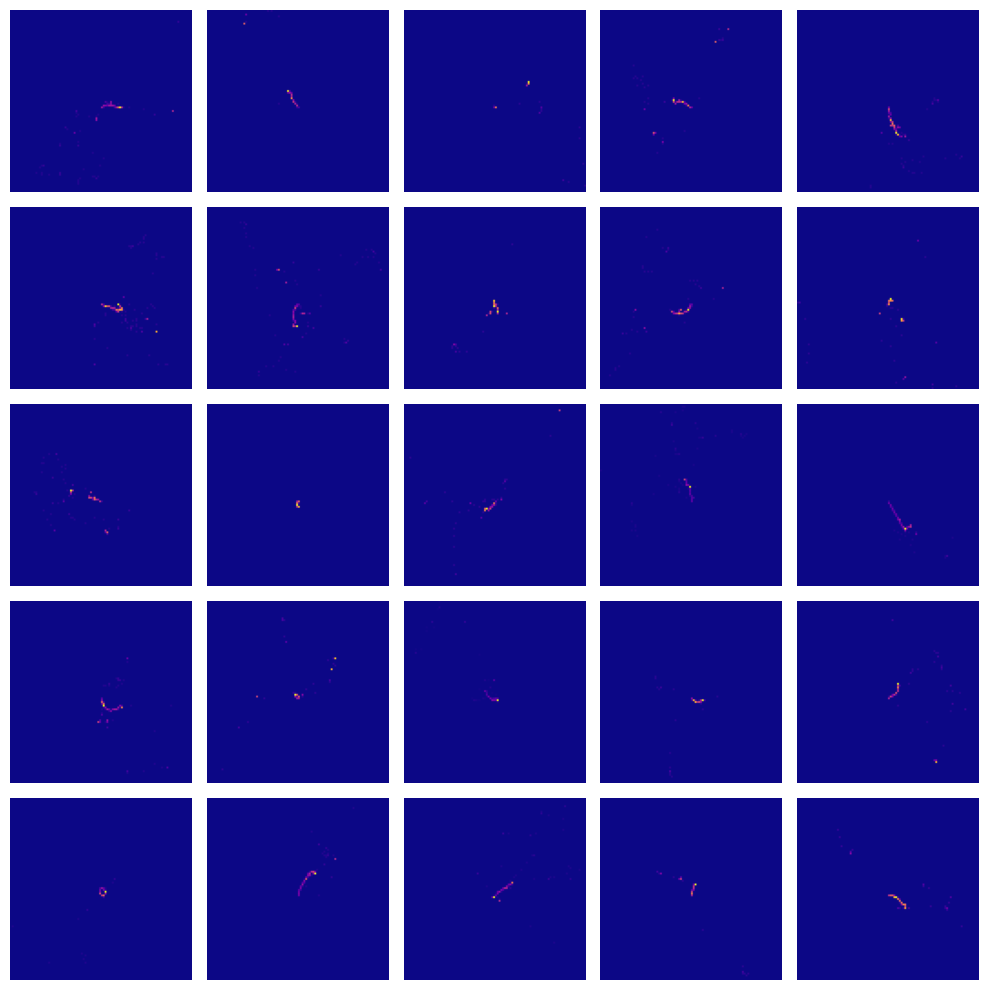

In [5]:
# Visualize the first 25 images in a 10x10 grid using matplotlib
fig, axes = plt.subplots(5, 5, figsize=(10, 10))

for i, ax in enumerate(axes.flat):
    ax.imshow(images[i], cmap="plasma") 
    #ax.set_title(f"Label = image{meta}")
    ax.axis("off")

plt.tight_layout()
plt.show()

Min pixel: 0.0
Max pixel: 106.0
Mean pixel: 0.02204712


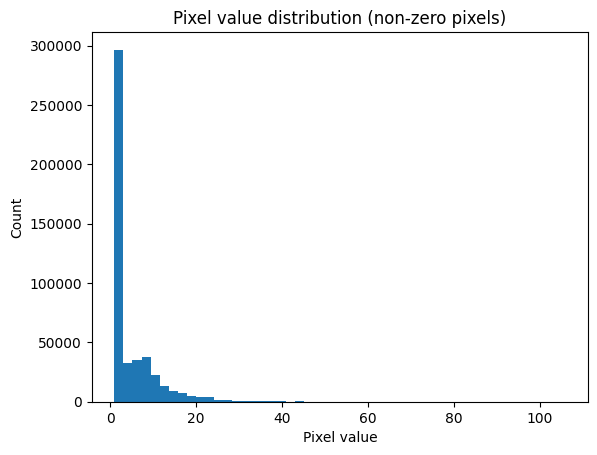

In [6]:
# Print basic statistics about the pixel values in the images to understand their range and distribution
print("Min pixel:", images.min())
print("Max pixel:", images.max())
print("Mean pixel:", images.mean())

# Flatten image array
pixels = images.flatten()

# Remove zero values
pixels = pixels[pixels > 0]

# Plot histogram of pixel values (non-zero pixels) to visualize their distribution
plt.hist(pixels, bins=50)
plt.xlabel("Pixel value")
plt.ylabel("Count")
plt.title("Pixel value distribution (non-zero pixels)")
plt.show()

To characterise the dataset, the distribution of pixel intensities is examined. In particular, the maximum pixel value of each image is used as a simple summary of signal strength.

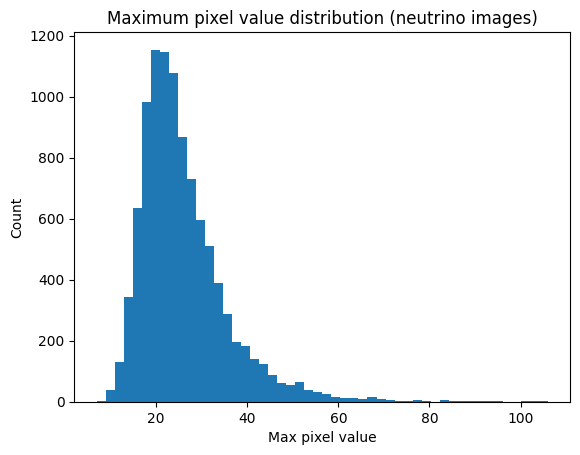

In [ ]:
def maxpixelvalue(images):
    '''
    Returns the maximum pixel value from each image in a dataset.

    Inputs
    - images : array-like collection of images

    Outputs
    - list of maximum pixel values for each image
    '''
    return [np.max(i) for i in images]

max_vals = maxpixelvalue(images)

plt.hist(max_vals, bins=50)
plt.xlabel("Max pixel value")
plt.ylabel("Count")
plt.title("Maximum pixel value distribution (neutrino images)")
plt.show()

## Functions for Main Task

In [8]:
# Prepare function to use for both sklearn and keras models to evaluate accuracy, confusion matrix, and ROC curve

#
def get_accuracy_sklearn(model, X, y):
    """
    Compute classification accuracy for a scikit-learn model.

    Parameters
    ----------
    model : estimator
        Trained model with `.predict()`.
    X : array-like
        Input features.
    y : array-like
        True labels.

    Returns
    -------
    float
        Accuracy score.
    """

    y_pred = model.predict(X)
    return accuracy_score(y, y_pred)

def plot_conf_matrix_sklearn(model, X, y, title="Confusion Matrix"):
    """
    Plot confusion matrix for a scikit-learn model.

    Returns
    -------
    ndarray
        Confusion matrix (labels: 0 = Noise, 1 = Neutrino).
    """

    y_pred = model.predict(X)
    cm = confusion_matrix(y, y_pred, labels=[0, 1])
    ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["Noise", "Neutrino"]
    ).plot(cmap="plasma", values_format="d")
    plt.title(title)
    plt.show()
    return cm

def plot_roc_curve_sklearn(model, X, y, title="ROC Curve"):
    """
    Plot ROC curve and compute AUC for a scikit-learn model.

    Returns
    -------
    tuple
        (fpr, tpr, auc)
    """

    y_prob = model.predict_proba(X)[:, 1]

    fpr, tpr, thresholds = roc_curve(y, y_prob)
    auc = roc_auc_score(y, y_prob)

    plt.figure()
    plt.plot(fpr, tpr, label=f"AUC = {auc:.3f}")
    plt.plot([0, 1], [0, 1], linestyle="--")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(title)
    plt.legend()
    plt.show()

    return fpr, tpr, auc





def get_accuracy_keras(model, X, y):
    """
    Compute accuracy for a Keras binary classifier using 0.5 threshold.
    """

    y_prob = model.predict(X, verbose=0).ravel()
    y_pred = (y_prob >= 0.5).astype(int)
    return accuracy_score(y, y_pred)



def plot_conf_matrix_keras(model, X, y, title="Confusion Matrix"):
    """
    Plot confusion matrix for a Keras binary classifier.

    Returns
    -------
    ndarray
        Confusion matrix.
    """

    y_prob = model.predict(X, verbose=0).ravel()
    y_pred = (y_prob >= 0.5).astype(int)

    cm = confusion_matrix(y, y_pred, labels=[0, 1])

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["Noise", "Neutrino"]
    )
    disp.plot(cmap="plasma", values_format="d")
    plt.title(title)
    plt.show()

    return cm



def plot_roc_curve_keras(model, X, y, title="ROC Curve"):
    """
    Plot ROC curve and compute AUC for a Keras model.

    Returns
    -------
    tuple
        (fpr, tpr, auc)
    """

    y_prob = model.predict(X, verbose=0).ravel()

    fpr, tpr, thresholds = roc_curve(y, y_prob)
    auc = roc_auc_score(y, y_prob)

    plt.plot(fpr, tpr, label=f"AUC = {auc:.3f}")
    plt.plot([0, 1], [0, 1], linestyle="--")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(title)
    plt.legend()
    plt.show()

    return fpr, tpr, auc



# Make a plot of the training and validation loss and accuracy over epochs to see how the model trained
def plot_training_history(history, title="Model Training History"):
    """
    Plot training and validation loss and accuracy over epochs.
    """

    # Loss plot
    plt.plot(history.history["loss"], label="Training loss")
    plt.plot(history.history["val_loss"], label="Validation loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(title + " Loss")
    plt.legend()
    plt.show()

    # Accuracy plot
    plt.plot(history.history["accuracy"], label="Training accuracy")
    plt.plot(history.history["val_accuracy"], label="Validation accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title(title + " Accuracy")
    plt.legend()
    plt.show()



def get_metrics(y_true, y_pred):
    """
    Compute accuracy, false positive rate, and false negative rate.

    Returns
    -------
    tuple
        (accuracy, FPR, FNR)
    """
    
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()

    accuracy = (tp + tn) / (tp + tn + fp + fn)
    false_positive_rate = fp / (fp + tn) if (fp + tn) > 0 else 0.0
    false_negative_rate = fn / (fn + tp) if (fn + tp) > 0 else 0.0

    return accuracy, false_positive_rate, false_negative_rate







## Building Initial Classifiers

The primary task is binary classification. True neutrino events are treated as signal (class 1), while simulated noise-only images are treated as background (class 0).

### Logistic Regression Model
Logistic regression is used as a simple baseline model. The image is flattened into pixel values, and a linear decision boundary is learned using a sigmoid function. This approach is fast and easy to train. However, it does not preserve spatial structure, so it cannot capture local features in the image.

(20000, 100, 100)
(20000,)
(array([0, 1]), array([10000, 10000]))
Train accuracy: 0.9993571428571428
Validation accuracy: 0.9993333333333333
Test accuracy: 0.9993333333333333


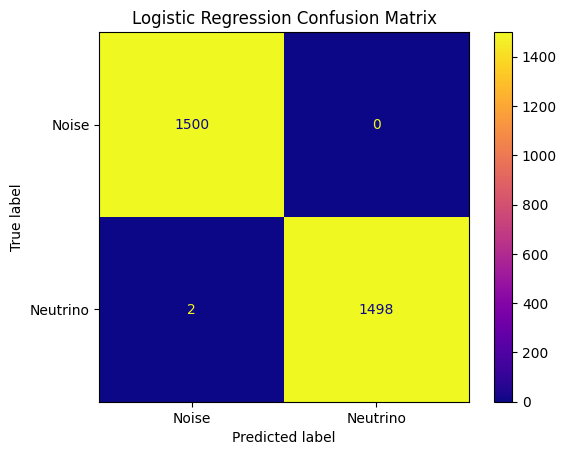

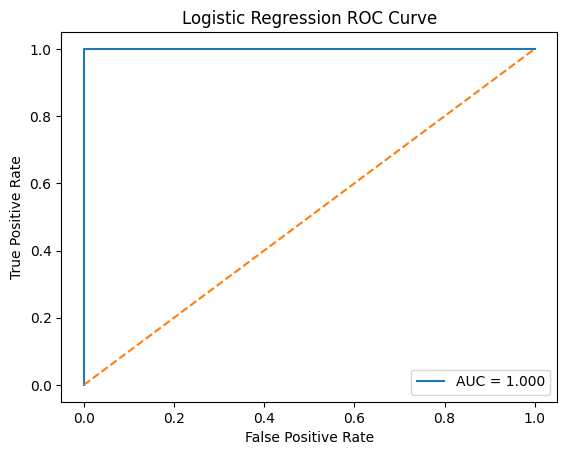

(LogisticRegression(max_iter=1000),
 np.float64(0.9993333333333333),
 np.float64(0.0),
 np.float64(0.0013333333333333333),
 array([1, 1, 1, ..., 1, 1, 0], shape=(3000,)),
 array([1, 1, 1, ..., 1, 1, 0], shape=(3000,)))

In [9]:
# Real neutrino images
signal_images = images.copy()
signal_labels = np.ones(signal_images.shape[0], dtype=int)

# Make blank noise images with same shape
noise_images = np.random.normal(
    loc=0.0,
    scale=0.02,
    size=images.shape
)

# Clip so values stay sensible
noise_images = np.clip(noise_images, 0, None)
# Create labels for noise images (0 for noise)
noise_labels = np.zeros(noise_images.shape[0], dtype=int)



# Combine
X_all_lr = np.concatenate([signal_images, noise_images], axis=0)
y_all_lr = np.concatenate([signal_labels, noise_labels], axis=0)

# Check shapes and class balance
print(X_all_lr.shape)
print(y_all_lr.shape)
print(np.unique(y_all_lr, return_counts=True))


# Normalise
X_all_lr = X_all_lr.astype("float32")
X_all_lr = X_all_lr / X_all_lr.max()

# Flatten for logistic regression
X_all_lr = X_all_lr.reshape(X_all_lr.shape[0], -1)

# Create Function to train logistic regression model and evaluate metrics and plots
def train_logistic_regression(X_all_lr, y_all_lr, show_plots=False):
    """
    Train and evaluate a logistic regression classifier.

    The dataset is split into training, validation, and test sets using a
    70/15/15 split with stratification to preserve class balance. The model
    is trained on the training set, evaluated on the test set, and can
    optionally display accuracy scores, a confusion matrix, and an ROC curve.

    Parameters
    ----------
    X_all_lr : array-like
        Input feature array for logistic regression.
    y_all_lr : array-like
        Binary class labels corresponding to `X_all_lr`.
    show_plots : bool, optional
        If True, prints training, validation, and test accuracy, and displays
        the confusion matrix and ROC curve.

    Returns
    -------
    tuple
        model_lr : LogisticRegression
            Trained logistic regression model.
        acc : float
            Test set accuracy.
        fpr : float
            False positive rate on the test set.
        fnr : float
            False negative rate on the test set.
        y_test_lr : array-like
            True labels for the test set.
        y_pred_lr : array-like
            Predicted labels for the test set.
    """
    
    # Split into train, val, test
    X_train_lr, X_temp_lr, y_train_lr, y_temp_lr = train_test_split(
        X_all_lr, y_all_lr, test_size=0.3, random_state=42, stratify=y_all_lr
    )

    X_val_lr, X_test_lr, y_val_lr, y_test_lr = train_test_split(
        X_temp_lr, y_temp_lr, test_size=0.5, random_state=42, stratify=y_temp_lr
    )

    # Model
    model_lr = LogisticRegression(max_iter=1000)
    model_lr.fit(X_train_lr, y_train_lr)

    # Predictions
    y_pred_lr = model_lr.predict(X_test_lr)

    # Metrics
    acc, fpr, fnr = get_metrics(y_test_lr, y_pred_lr)

    if show_plots:
        print("Train accuracy:", get_accuracy_sklearn(model_lr, X_train_lr, y_train_lr))
        print("Validation accuracy:", get_accuracy_sklearn(model_lr, X_val_lr, y_val_lr))
        print("Test accuracy:", acc)

        plot_conf_matrix_sklearn(model_lr, X_test_lr, y_test_lr, title="Logistic Regression Confusion Matrix")
        plot_roc_curve_sklearn(model_lr, X_test_lr, y_test_lr, title="Logistic Regression ROC Curve")

    return model_lr, acc, fpr, fnr, y_test_lr, y_pred_lr

train_logistic_regression(X_all_lr, y_all_lr, show_plots=True)

### Dense Neural Network
The dense neural network extends logistic regression by adding hidden layers with non-linear activations. This allows the model to learn more complex relationships between pixel values. However, the input is still flattened, so spatial information is not preserved. This limits its ability to identify structured signal features. [[[7]](#ref7)]

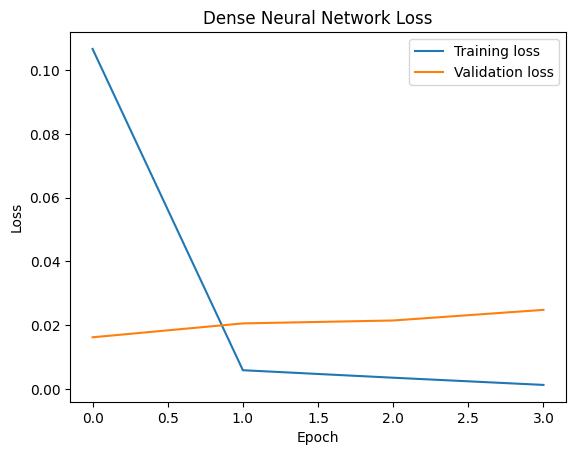

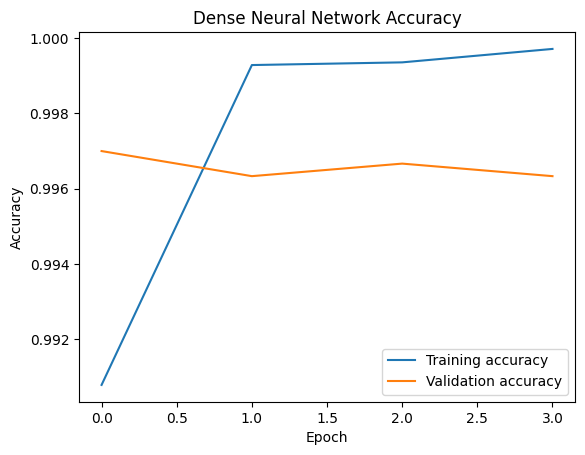

Dense NN Training Accuracy: 0.9993571428571428
Dense NN Validation Accuracy: 0.997
Dense NN Test Accuracy: 0.998


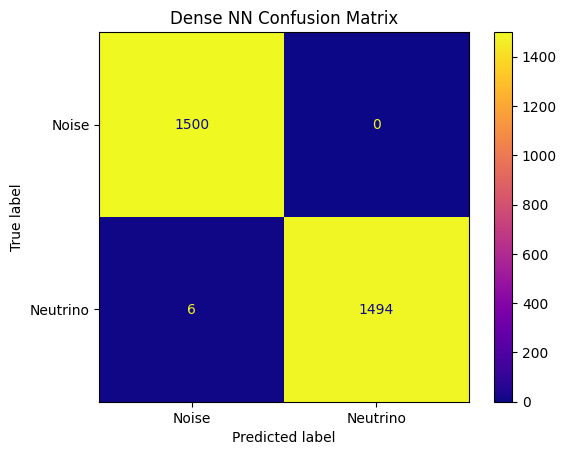

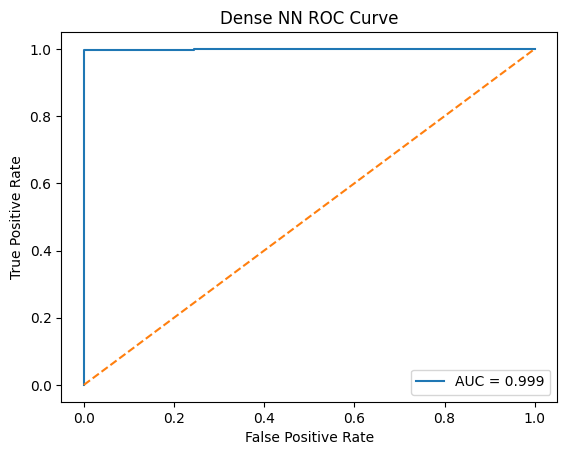

(<Sequential name=sequential, built=True>,
 np.float64(0.998),
 np.float64(0.0),
 np.float64(0.004),
 array([1, 1, 1, ..., 1, 1, 0], shape=(3000,)),
 array([1, 1, 1, ..., 1, 1, 0], shape=(3000,)))

In [10]:
# Real images
signal_images = images.copy()
signal_labels = np.ones(signal_images.shape[0], dtype=int)

# Noise images
noise_images = np.random.normal(loc=0.0, scale=0.02, size=images.shape)
noise_images = np.clip(noise_images, 0, None)
noise_labels = np.zeros(noise_images.shape[0], dtype=int)

# Combine both classes
X_all = np.concatenate([signal_images, noise_images], axis=0).astype("float32")
y_all = np.concatenate([signal_labels, noise_labels], axis=0)

# Normalise
X_all = X_all / X_all.max()
X_all_dnn = X_all.reshape(X_all.shape[0], -1)

def train_dense_nn(X_all_dnn, y_all_dnn, show_plots=False):
    """
    Train and evaluate a dense (fully connected) neural network classifier.

    The dataset is split into training, validation, and test sets using a
    70/15/15 stratified split. A feedforward neural network with two hidden
    layers is trained using binary cross-entropy loss. The model is evaluated
    on the test set, and optional plots can be generated to assess performance.

    Parameters
    ----------
    X_all_dnn : array-like
        Input feature array.
    y_all_dnn : array-like
        Binary class labels corresponding to `X_all_dnn`.
    show_plots : bool, optional
        If True, displays training history, accuracy scores, confusion matrix,
        and ROC curve.

    Returns
    -------
    tuple
        model_dnn : keras.Model
            Trained dense neural network model.
        acc : float
            Test set accuracy.
        fpr : float
            False positive rate on the test set.
        fnr : float
            False negative rate on the test set.
        y_test_dnn : array-like
            True labels for the test set.
        y_pred_dnn : array-like
            Predicted labels for the test set.
    """
    
    # Train / validation / test split
    X_train_dnn, X_temp_dnn, y_train_dnn, y_temp_dnn = train_test_split(X_all_dnn, y_all_dnn, test_size=0.3, random_state=42, stratify=y_all_dnn)
    X_val_dnn, X_test_dnn, y_val_dnn, y_test_dnn = train_test_split(X_temp_dnn, y_temp_dnn, test_size=0.5, random_state=42, stratify=y_temp_dnn)

    # Model
    model_dnn = keras.Sequential([
        keras.Input(shape=(X_train_dnn.shape[1],)),
        layers.Dense(128, activation="relu"),
        layers.Dense(64, activation="relu"),
        layers.Dense(1, activation="sigmoid")
    ])

    # Compile the model with Adam optimizer and binary cross-entropy loss
    model_dnn.compile(
        optimizer="adam",
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    # Early stopping callback to prevent overfitting
    callback = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
    )  
    
    # Train the model
    history_dnn = model_dnn.fit(
        X_train_dnn, y_train_dnn,
        epochs=10,
        batch_size=32,
        validation_data=(X_val_dnn, y_val_dnn),
        verbose=0,
        callbacks=[callback]
    )

    # Predictions and metrics
    y_pred_dnn = (model_dnn.predict(X_test_dnn, verbose=0) > 0.5).astype(int).flatten()
    acc, fpr, fnr = get_metrics(y_test_dnn, y_pred_dnn)

    # Optional plots and metrics display
    if show_plots:
        plot_training_history(history_dnn,"Dense Neural Network")
        print("Dense NN Training Accuracy:", get_accuracy_keras(model_dnn, X_train_dnn, y_train_dnn))
        print("Dense NN Validation Accuracy:", get_accuracy_keras(model_dnn, X_val_dnn, y_val_dnn))
        print("Dense NN Test Accuracy:", acc)

        plot_conf_matrix_keras(model_dnn, X_test_dnn, y_test_dnn, title="Dense NN Confusion Matrix")
        plot_roc_curve_keras(model_dnn, X_test_dnn, y_test_dnn, title="Dense NN ROC Curve")

    return model_dnn, acc, fpr, fnr, y_test_dnn, y_pred_dnn

train_dense_nn(X_all_dnn, y_all, show_plots=True)

### Convolution Neural Network (CNN)
The CNN uses convolutional layers to extract local spatial features from the image. Filters respond to clustered high-intensity pixels, while pooling layers reduce the image size. This allows the model to identify track-like structures from neutrino interactions. As a result, it performs better than the baseline models at low noise. [[6]](#ref6)[[7]](#ref7)

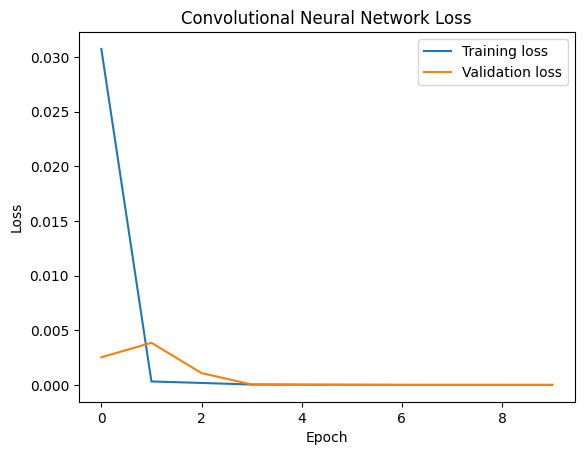

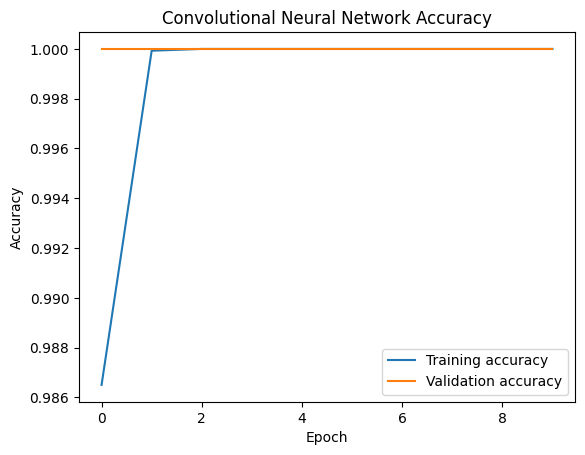

Convolutional NN Training Accuracy: 1.0
Convolutional NN Validation Accuracy: 1.0
Convolutional NN Test Accuracy: 1.0


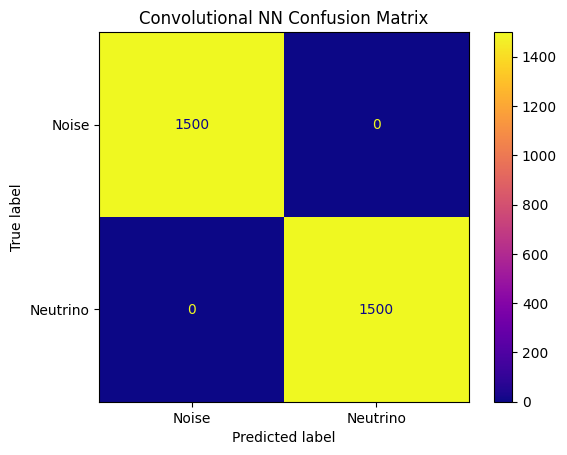

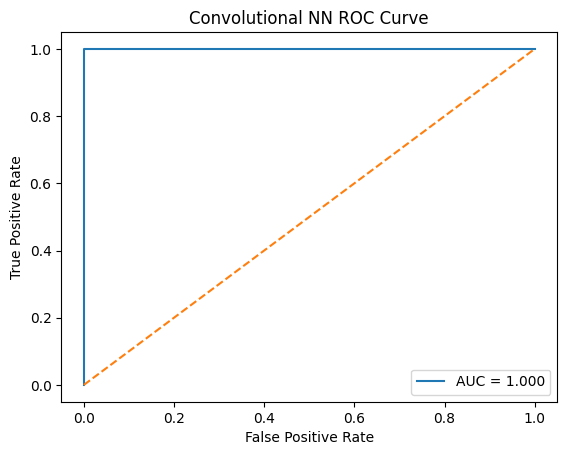

(<Sequential name=sequential_1, built=True>,
 np.float64(1.0),
 np.float64(0.0),
 np.float64(0.0),
 array([1, 1, 1, ..., 1, 1, 0], shape=(3000,)),
 array([1, 1, 1, ..., 1, 1, 0], shape=(3000,)),
 <keras.src.callbacks.history.History at 0x17e44c220>)

In [11]:
# combine real and noise images
X_all = np.concatenate([signal_images, noise_images], axis=0).astype("float32")
y_all = np.concatenate([signal_labels, noise_labels], axis=0)

# Normalise
X_all = X_all / X_all.max()
X_all_cnn = X_all.reshape(X_all.shape[0], X_all.shape[1], X_all.shape[2], 1)


def train_cnn(X_all_cnn, y_all_cnn, show_plots=False):
    """
    Train and evaluate a convolutional neural network (CNN) for image classification.

    The dataset is split into training, validation, and test sets using a
    70/15/15 stratified split. A CNN with two convolutional layers and
    max-pooling is used to extract spatial features from the input images.
    The model is trained using binary cross-entropy loss and evaluated on
    the test set. Optional plots can be generated to assess performance.

    Parameters
    ----------
    X_all_cnn : array-like
        Input image data of shape (N, 100, 100, 1).
    y_all_cnn : array-like
        Binary class labels corresponding to `X_all_cnn`.
    show_plots : bool, optional
        If True, displays training history, accuracy scores, confusion matrix,
        and ROC curve.

    Returns
    -------
    tuple
        model_cnn : keras.Model
            Trained CNN model.
        acc : float
            Test set accuracy.
        fpr : float
            False positive rate on the test set.
        fnr : float
            False negative rate on the test set.
        y_test_cnn : array-like
            True labels for the test set.
        y_pred_cnn : array-like
            Predicted labels for the test set.
        history_cnn : keras.callbacks.History
            Training history object.
    """


    # Train / validation / test split
    X_train_cnn, X_temp_cnn, y_train_cnn, y_temp_cnn = train_test_split(X_all_cnn, y_all_cnn, test_size=0.3, random_state=42, stratify=y_all_cnn)
    X_val_cnn, X_test_cnn, y_val_cnn, y_test_cnn = train_test_split(X_temp_cnn, y_temp_cnn, test_size=0.5, random_state=42, stratify=y_temp_cnn)

    # Model
    model_cnn = keras.Sequential([
        keras.Input(shape=(100, 100, 1)),
        layers.Conv2D(16, (5, 5), activation="relu"),
        layers.MaxPooling2D((2, 2)),
        layers.Conv2D(32, (5, 5), activation="relu"),
        layers.MaxPooling2D((2, 2)),
        layers.Flatten(),
        layers.Dense(64, activation="relu"),
        layers.Dense(1, activation="sigmoid")
    ])

    # Compile the model with Adam optimizer and binary cross-entropy loss
    model_cnn.compile(
        optimizer="adam",
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    # Early stopping callback to prevent overfitting
    callback = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
    )  
    
    # Train the model
    history_cnn = model_cnn.fit(
        X_train_cnn, y_train_cnn,
        epochs=10,
        validation_data=(X_val_cnn, y_val_cnn),
        verbose=0,
        callbacks=[callback]
    )

    # Predictions and metrics
    y_pred_cnn = (model_cnn.predict(X_test_cnn, verbose=0) > 0.5).astype(int).flatten()
    acc, fpr, fnr = get_metrics(y_test_cnn, y_pred_cnn)

    # Optional plots and metrics display
    if show_plots:
        plot_training_history(history_cnn, "Convolutional Neural Network" )
        print("Convolutional NN Training Accuracy:", get_accuracy_keras(model_cnn, X_train_cnn, y_train_cnn))
        print("Convolutional NN Validation Accuracy:", get_accuracy_keras(model_cnn, X_val_cnn, y_val_cnn))
        print("Convolutional NN Test Accuracy:", acc)

        plot_conf_matrix_keras(model_cnn, X_test_cnn, y_test_cnn, title="Convolutional NN Confusion Matrix")
        plot_roc_curve_keras(model_cnn, X_test_cnn, y_test_cnn, title="Convolutional NN ROC Curve")

    return model_cnn, acc, fpr, fnr, y_test_cnn, y_pred_cnn, history_cnn


train_cnn(X_all_cnn, y_all, show_plots=True)

## Task 1: Generating Electronic Noise

Electronic noise is simulated by sampling pixel fluctuations from a zero-mean Gaussian distribution. The noise level is controlled by the standard deviation, allowing progressively more challenging detector conditions to be studied.

In [12]:
def addNoiseToImages(noise, data):
    """
    Add zero-centred Gaussian noise to image data.

    Noise is sampled from a normal distribution with mean 0 and standard
    deviation equal to `noise`. This models symmetric detector/electronic
    noise. Pixel values are clipped to remain within valid bounds.

    Parameters
    ----------
    noise : float
        Standard deviation of the Gaussian noise.
    data : array-like
        Input image data.

    Returns
    -------
    ndarray
        Noisy image data with values clipped to [0, 255].
    """


    # Convert input to TensorFlow tensor
    data = tf.convert_to_tensor(data, dtype=tf.float32)


    # Generate Gaussian (normal) noise
    noise_tensor = tf.random.normal(
        shape=tf.shape(data),
        mean=0.0,                    # zero-centred noise
        stddev=float(noise),         # noise strength
        dtype=tf.float32
    )

 
    # Add noise to images and clip to valid pixel range
    noisy = data + noise_tensor
    noisy = tf.clip_by_value(noisy, 0.0, 255.0)

    return noisy.numpy()        

                                                                                   



def make_dataset_with_noise(images, noise_level):
    """
    Create a binary classification dataset with added noise.

    Real neutrino images are used as the signal class, while blank images
    represent background. The same noise level is applied to both classes
    to simulate detector/electronics noise. Pixel values are normalised
    to the range [0, 1].

    Parameters
    ----------
    images : array-like
        Input neutrino images.
    noise_level : float
        Noise amplitude applied to both signal and background.

    Returns
    -------
    tuple
        X_all : ndarray
            Combined dataset of noisy images.
        y_all : ndarray
            Corresponding binary labels (1 = neutrino, 0 = background).
    """
    
    # Real neutrino images
    signal_images = images.astype("float32").copy()
    signal_labels = np.ones(signal_images.shape[0], dtype=int)

    # Blank images for the background class
    blank_images = np.zeros_like(images, dtype="float32")

    # Add the same type of electronics noise to BOTH classes
    noisy_signal_images = addNoiseToImages(noise_level, signal_images).astype("float32")
    noisy_background_images = addNoiseToImages(noise_level, blank_images).astype("float32")

    # Labels for background
    background_labels = np.zeros(noisy_background_images.shape[0], dtype=int)

    # Combine both classes
    X_all = np.concatenate([noisy_signal_images, noisy_background_images], axis=0)
    y_all = np.concatenate([signal_labels, background_labels], axis=0)

    # Normalise pixel values
    X_all = X_all / 255.0

    return X_all, y_all

def get_noise_image_max_pixels(images, noise_level):
    '''
    Returns the maximum pixel value from each generated noise-only image

    Inputs
    - images       - image array used only for shape reference
    - noise_level  - noise amplitude

    Outputs
    - max_pixels   - array of max pixel values for each noise-only image
    '''

    # Create blank images
    blank_images = np.zeros_like(images, dtype="float32")

    # Add noise to blank images
    noisy_background_images = addNoiseToImages(noise_level, blank_images).astype("float32")

    # Find maximum pixel in each image
    max_pixels = np.max(noisy_background_images, axis=(1, 2))

    return max_pixels

def plot_noise_max_pixel_overlay(images, noise_levels):
    '''
    Plots overlaid histograms of max pixel distributions for multiple noise levels

    Inputs
    - images        - image array used for shape reference
    - noise_levels  - list of noise amplitudes

    Outputs
    - None
    '''

    plt.figure(figsize=(10, 6))

    # Remove noise level 0 from overlay because it dominates the low end
    noise_levels_to_plot = [n for n in noise_levels if n > 0]

    # Collect all max pixel values first so all histograms use identical bins
    all_max_pixels = []
    for noise_level in noise_levels_to_plot:
        max_pixels = get_noise_image_max_pixels(images, noise_level)
        all_max_pixels.append(max_pixels)

    # Common bin edges
    global_min = min(np.min(arr) for arr in all_max_pixels)
    global_max = max(np.max(arr) for arr in all_max_pixels)
    bins = np.linspace(global_min, global_max, 80)

    # Plot each histogram
    for noise_level, max_pixels in zip(noise_levels_to_plot, all_max_pixels):
        plt.hist(
            max_pixels,
            bins=bins,
            histtype='step',
            linewidth=2,
            label=f'Noise lvl: {noise_level}'
        )

        # Mean line
        plt.axvline(
            np.mean(max_pixels),
            linestyle='--',
            linewidth=1
        )

    plt.xlabel('Pixel value')
    plt.ylabel('Frequency')
    plt.title('Generated noise image max pixel distribution')
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

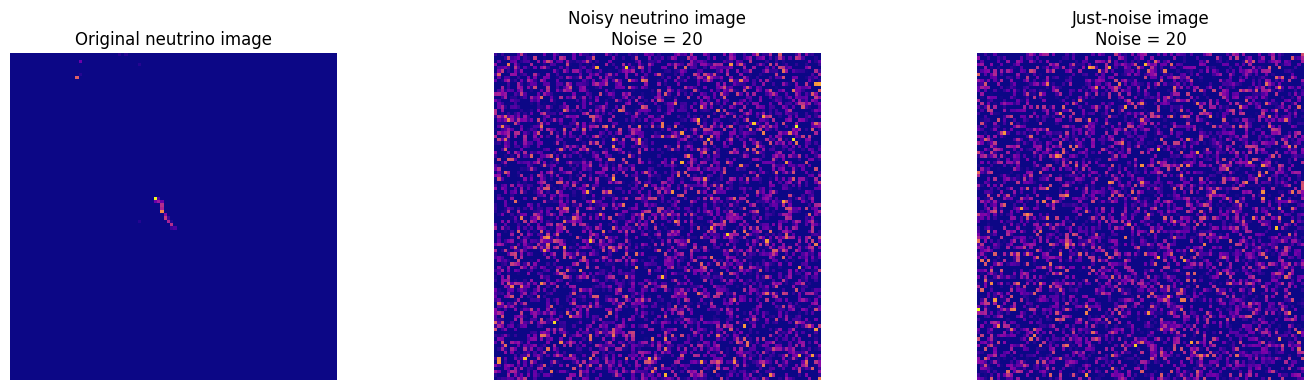

In [13]:
# Show example noisy images for a given noise level to visualise the effect of the noise on both signal and background classes

noise_level = 20  # Chosen noise level

# Create example signal and blank images to show the effect of noise
signal_example = images[1].astype("float32")
blank_example = np.zeros_like(signal_example, dtype="float32")

noisy_signal_example = addNoiseToImages(noise_level, signal_example)
noisy_background_example = addNoiseToImages(noise_level, blank_example)

# Plot original, noisy signal, and noisy background images side by side
plt.figure(figsize=(15, 4))

# Original image
plt.subplot(1, 3, 1)
plt.imshow(signal_example, cmap="plasma")
plt.title("Original neutrino image")
plt.axis("off")

# Noisy signal image
plt.subplot(1, 3, 2)
plt.imshow(noisy_signal_example, cmap="plasma")
plt.title(f"Noisy neutrino image\nNoise = {noise_level}")
plt.axis("off")

# Noisy background image
plt.subplot(1, 3, 3)
plt.imshow(noisy_background_example, cmap="plasma")
plt.title(f"Just-noise image\nNoise = {noise_level}")
plt.axis("off")

plt.tight_layout()
plt.show()

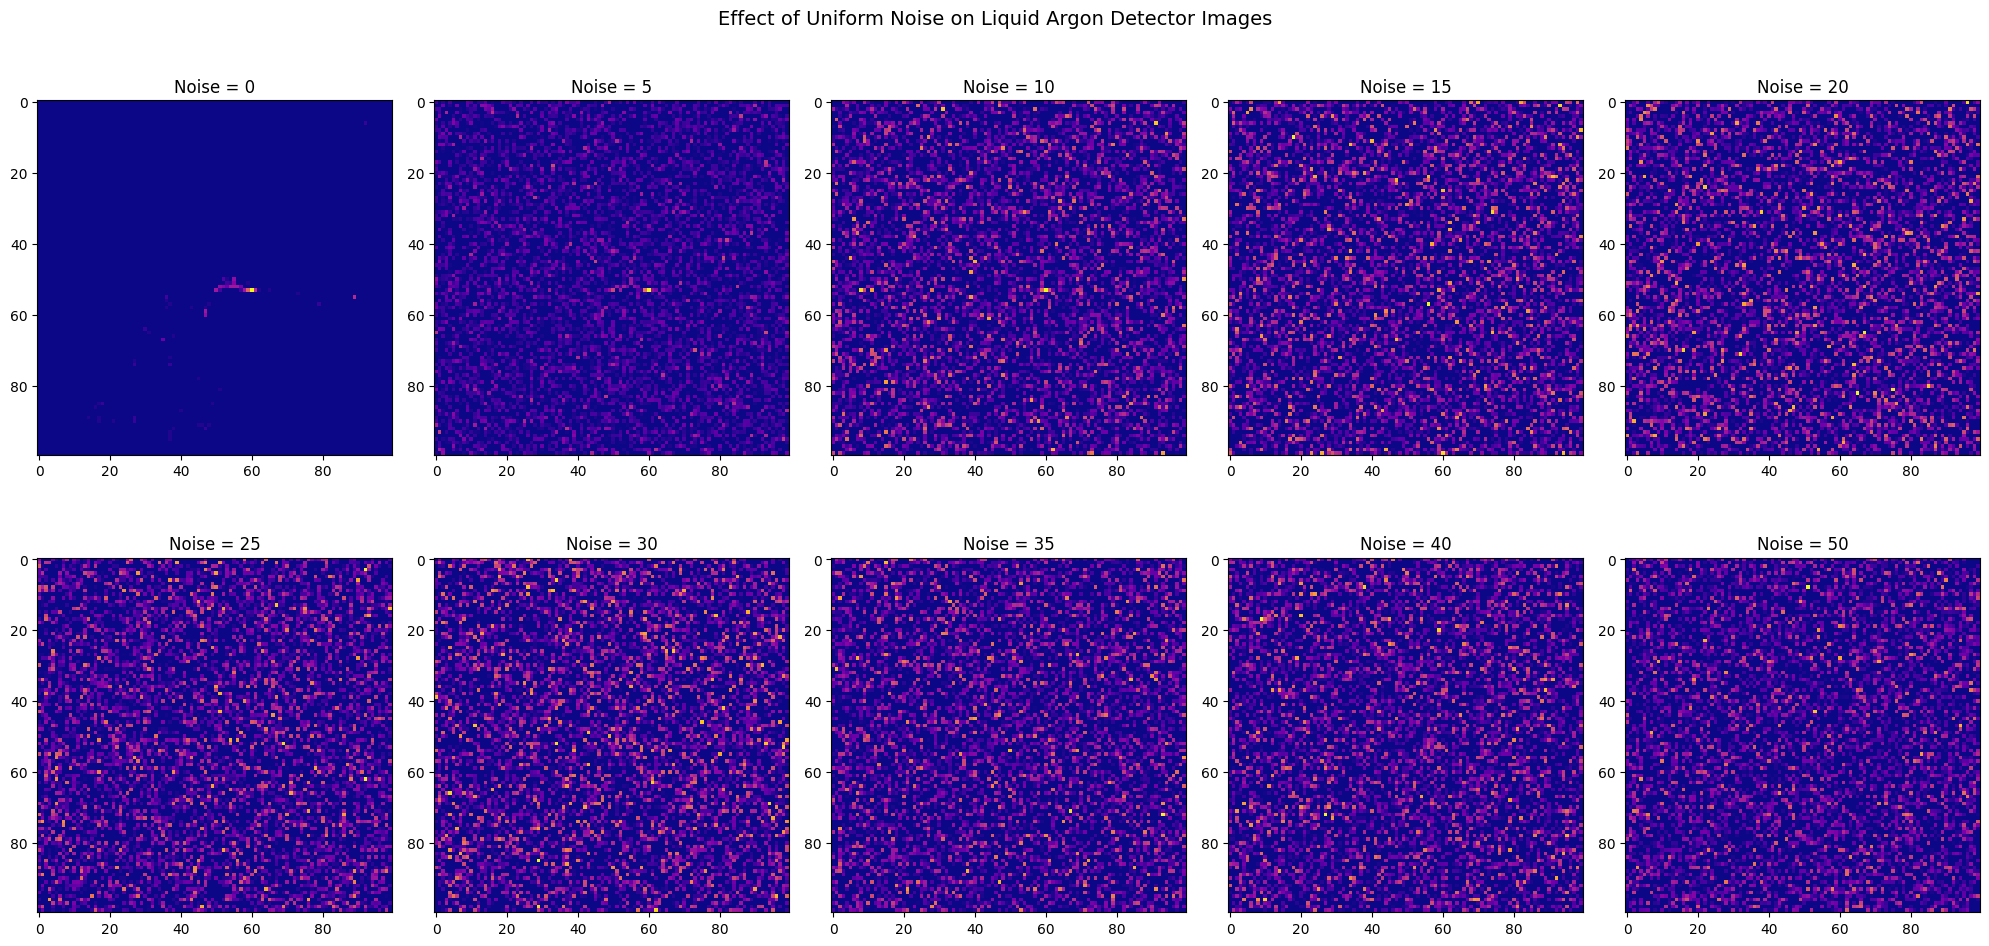

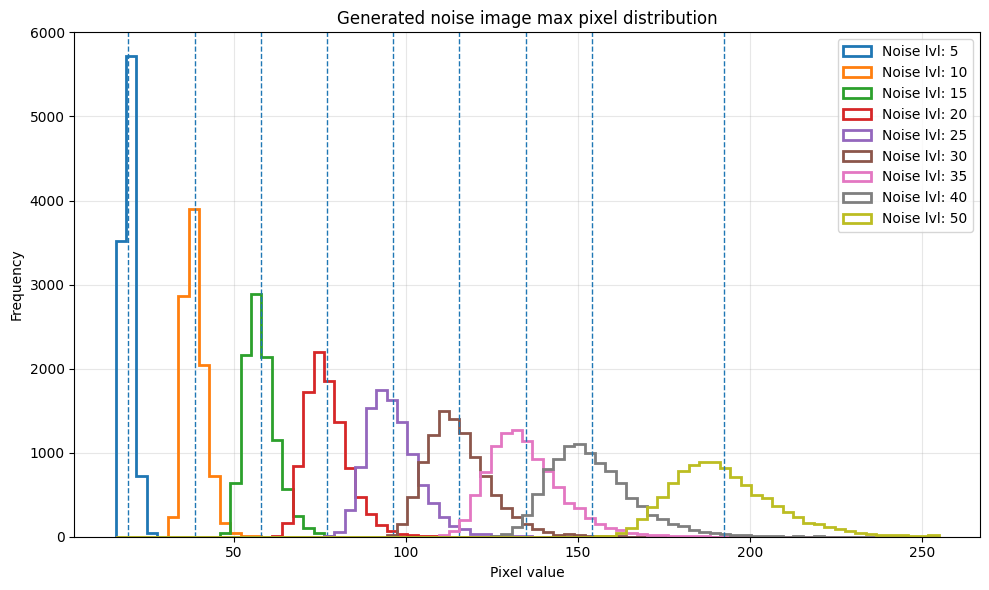

In [14]:
# Plot one image with different noise levels
image = images[0]                   
noise_levels = [0, 5, 10, 15, 20, 25, 30,35, 40, 50]        # different noise levels  

plt.figure(figsize=(20, 10))                                # Create a figure for subplots

for i, yNoise in enumerate(noise_levels):                   # Loop through each noise level
    plt.subplot(2, len(noise_levels)//2, i+1)               # Create subplot for each noise level
    noisy_image = addNoiseToImages(yNoise, image)           # Add noise to the image
    plt.imshow(noisy_image, cmap='plasma')                 # Plot the image
    plt.title(f"Noise = {yNoise}")                          # Set title with noise level

plt.suptitle("Effect of Uniform Noise on Liquid Argon Detector Images", fontsize=14)
plt.tight_layout()
plt.show()


plot_noise_max_pixel_overlay(images, noise_levels)

These histograms show how increasing noise shifts and broadens the background distribution. At intermediate noise levels, overlap with the signal distribution becomes significant.

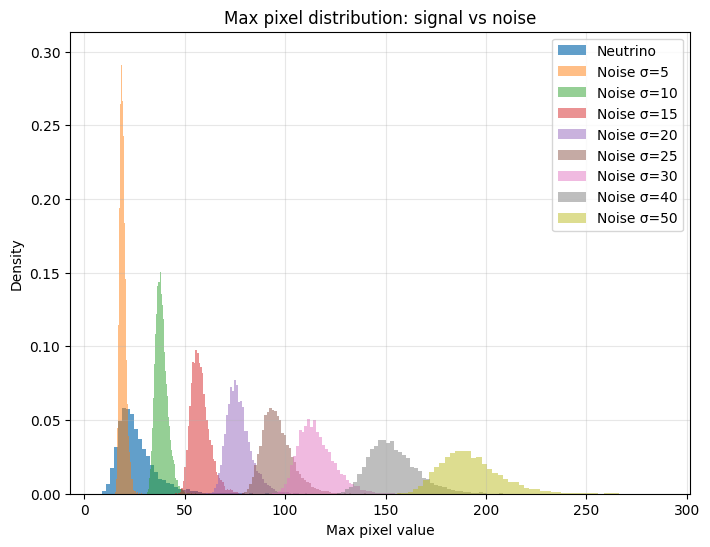

In [59]:
# Histogram: Max pixel comparison (signal vs noise)
def plot_maxpixel_distributions(signal_images, sigma_values):
    '''
    Plots overlapping histograms of max pixel values for:
    - Neutrino (signal) images
    - Noise images at different sigma levels

    Inputs:
    - signal_images : numpy array of shape (N, H, W)
    - sigma_values  : list of noise levels (e.g. [1, 3, 5])
    '''

    # Ensure numpy array
    signal_images = np.array(signal_images)


    # Signal max pixels
    signal_max = signal_images.reshape(len(signal_images), -1).max(axis=1)

    plt.figure(figsize=(8,6))

    plt.hist(signal_max,
             bins=50,
             alpha=0.7,
             label='Neutrino',
             density=True)

    
    # Noise distributions
    for sigma in sigma_values:

        # Generate noise images with SAME SHAPE
        noise_images = np.random.normal(
            loc=0.0,
            scale=sigma,
            size=signal_images.shape
        )

        # Clip (important for physical realism)
        noise_images = np.clip(noise_images, 0, None)

        # Max pixel values
        noise_max = noise_images.reshape(len(noise_images), -1).max(axis=1)

        plt.hist(noise_max,
                 bins=50,
                 alpha=0.5,
                 label=f'Noise σ={sigma}',
                 density=True)

   # Labels
    plt.xlabel('Max pixel value')
    plt.ylabel('Density')
    plt.title('Max pixel distribution: signal vs noise')

    plt.legend()
    plt.grid(alpha=0.3)

    plt.show()



# Call function
sigma_values = [ 5, 10, 15, 20, 25, 30, 40, 50]
plot_maxpixel_distributions(images, sigma_values)

## Task 2: Overlaying Noise onto Real Events and Testing

In [15]:
noise_levels = [0, 5, 10, 15, 20, 25, 30, 40, 50]

results = []
saved_predictions = {}

for noise_level in noise_levels:
    print("Running noise level:", noise_level)

    # Clear the Keras backend
    tf.keras.backend.clear_session()

    # Build dataset for this noise level
    X_all, y_all = make_dataset_with_noise(images, noise_level)

    # Shapes for each model
    X_all_lr = X_all.reshape(X_all.shape[0], -1)                                        # Logistic Regression
    X_all_dnn = X_all.reshape(X_all.shape[0], -1)                                       # Dense NN
    X_all_cnn = X_all.reshape(X_all.shape[0], X_all.shape[1], X_all.shape[2], 1)        # CNN


    # Train and evaluate each model
    # Logistic regression
    model_lr, acc_lr, fpr_lr, fnr_lr, y_test_lr, y_pred_lr = train_logistic_regression(X_all_lr, y_all, show_plots=False)
    results.append(["Logistic Regression", noise_level, acc_lr, fpr_lr, fnr_lr])
    saved_predictions[("Logistic Regression", noise_level)] = (y_test_lr, y_pred_lr)

    # Dense NN
    model_dnn, acc_dnn, fpr_dnn, fnr_dnn, y_test_dnn, y_pred_dnn = train_dense_nn( X_all_dnn, y_all, show_plots=False)
    results.append(["Dense NN", noise_level, acc_dnn, fpr_dnn, fnr_dnn])
    saved_predictions[("Dense NN", noise_level)] = (y_test_dnn, y_pred_dnn)

    # CNN
    model_cnn, acc_cnn, fpr_cnn, fnr_cnn, y_test_cnn, y_pred_cnn, history_cnn = train_cnn( X_all_cnn, y_all, show_plots=False)
    results.append(["CNN", noise_level, acc_cnn, fpr_cnn, fnr_cnn])
    saved_predictions[("CNN", noise_level)] = (y_test_cnn, y_pred_cnn)

results_df = pd.DataFrame(results, columns=["Model", "Noise Level", "Accuracy", "False Positive Rate", "False Negative Rate"])

# Round metrics to 3 decimal places for better readability
results_df["Accuracy"] = results_df["Accuracy"].round(3)
results_df["False Positive Rate"] = results_df["False Positive Rate"].round(3)
results_df["False Negative Rate"] = results_df["False Negative Rate"].round(3)


results_df

Running noise level: 0
Running noise level: 5
Running noise level: 10
Running noise level: 15
Running noise level: 20
Running noise level: 25
Running noise level: 30
Running noise level: 40
Running noise level: 50


,Model,Noise Level,Accuracy,False Positive Rate,False Negative Rate
0,Logistic Regression,0,0.999,0.000,0.002
1,Dense NN,0,1.000,0.000,0.000
2,CNN,0,1.000,0.000,0.000
3,Logistic Regression,5,0.863,0.092,0.183
4,Dense NN,5,0.810,0.263,0.116
5,CNN,5,0.962,0.018,0.059
6,Logistic Regression,10,0.664,0.315,0.357
7,Dense NN,10,0.610,0.611,0.169
8,CNN,10,0.500,0.000,1.000
9,Logistic Regression,15,0.568,0.420,0.444


## Task 3: Performance Evaluation

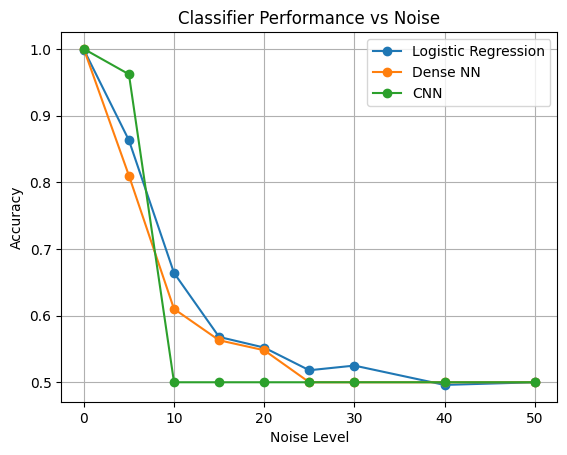

In [16]:
for model in results_df["Model"].unique():

    subset = results_df[results_df["Model"] == model]
    # plt.figure(figsize=(10, 6))
    plt.plot(
        subset["Noise Level"],
        subset["Accuracy"],
        marker="o",
        label=model
    )


plt.xlabel("Noise Level")
plt.ylabel("Accuracy")
plt.title("Classifier Performance vs Noise")
plt.legend()
plt.grid()
plt.show()

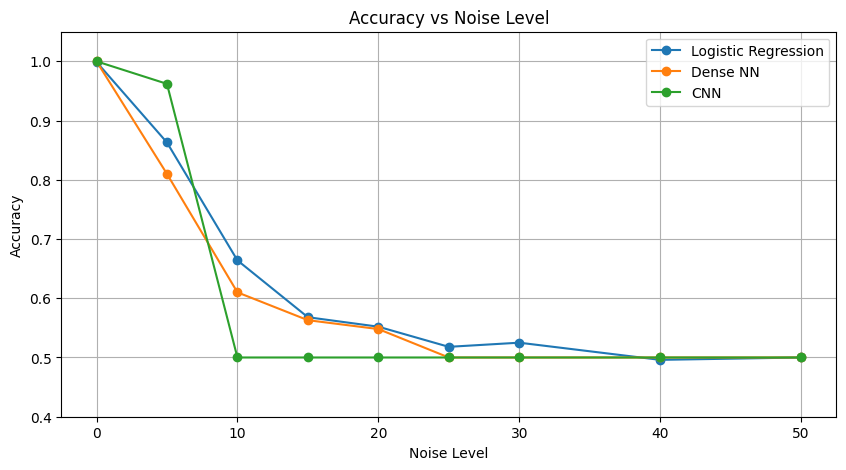

In [17]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

for model in results_df["Model"].unique():
    subset = results_df[results_df["Model"] == model]
    plt.plot(subset["Noise Level"], subset["Accuracy"], marker="o", label=model)

plt.xlabel("Noise Level")
plt.ylabel("Accuracy")
plt.title("Accuracy vs Noise Level")
plt.ylim(0.4, 1.05)
plt.grid(True)
plt.legend()
plt.show()

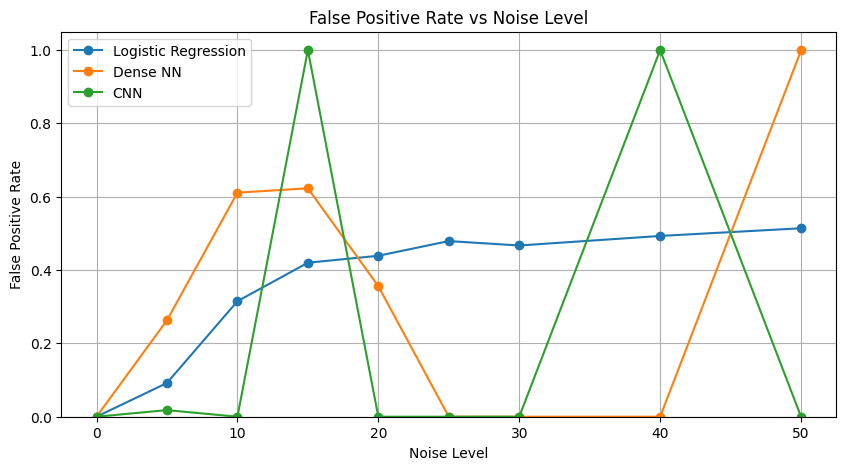

In [18]:
plt.figure(figsize=(10,5))

for model in results_df["Model"].unique():
    subset = results_df[results_df["Model"] == model]
    plt.plot(subset["Noise Level"], subset["False Positive Rate"], marker="o", label=model)

plt.xlabel("Noise Level")
plt.ylabel("False Positive Rate")
plt.title("False Positive Rate vs Noise Level")
plt.ylim(0, 1.05)
plt.grid(True)
plt.legend()
plt.show()

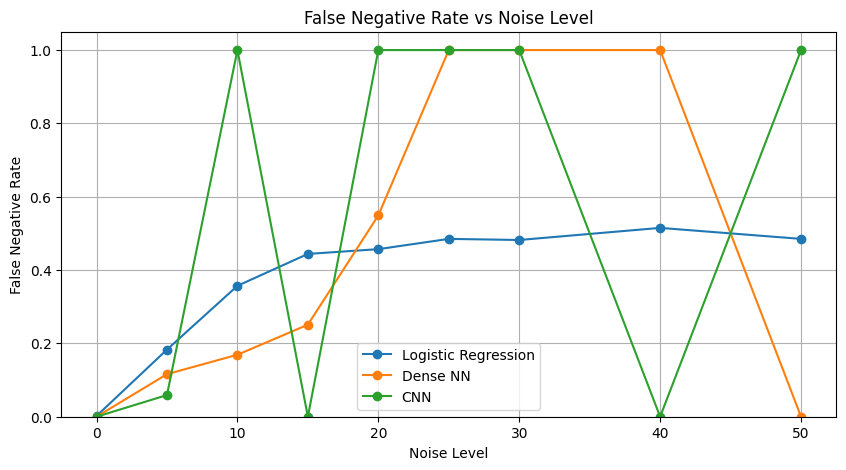

In [19]:
plt.figure(figsize=(10,5))

for model in results_df["Model"].unique():
    subset = results_df[results_df["Model"] == model]
    plt.plot(subset["Noise Level"], subset["False Negative Rate"], marker="o", label=model)

plt.xlabel("Noise Level")
plt.ylabel("False Negative Rate")
plt.title("False Negative Rate vs Noise Level")
plt.ylim(0, 1.05)
plt.grid(True)
plt.legend()
plt.show()

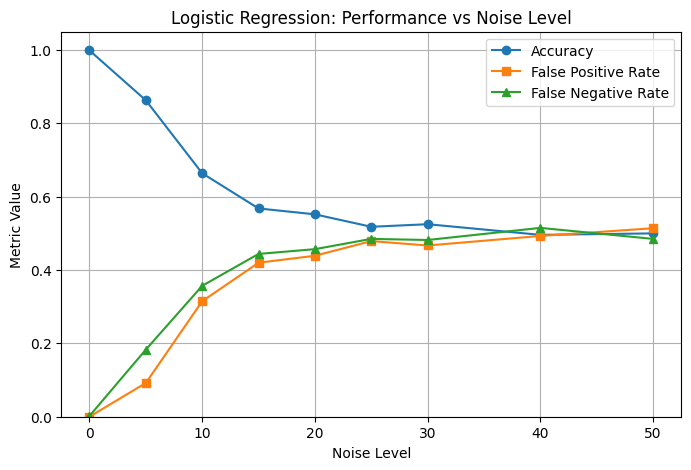

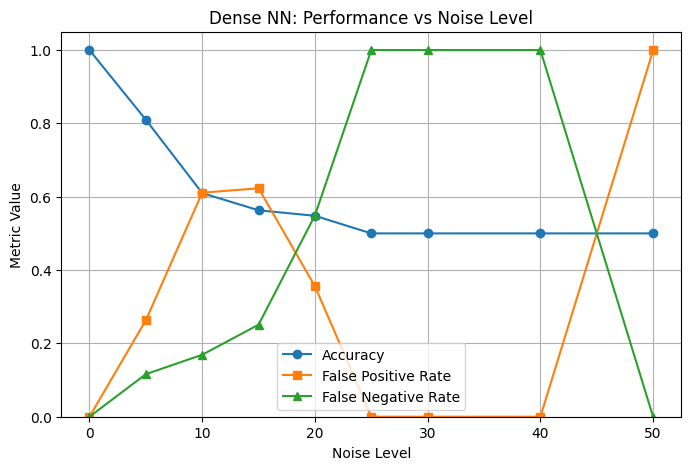

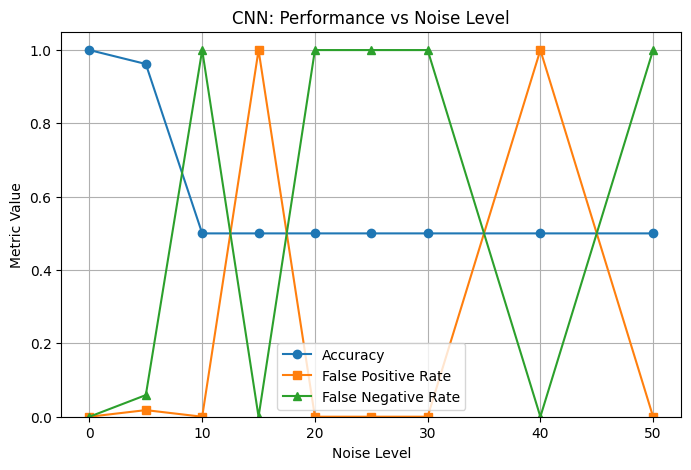

In [20]:


subset = results_df[results_df["Model"] == "Logistic Regression"]

plt.figure(figsize=(8,5))
plt.plot(subset["Noise Level"], subset["Accuracy"], marker="o", label="Accuracy")
plt.plot(subset["Noise Level"], subset["False Positive Rate"], marker="s", label="False Positive Rate")
plt.plot(subset["Noise Level"], subset["False Negative Rate"], marker="^", label="False Negative Rate")

plt.xlabel("Noise Level")
plt.ylabel("Metric Value")
plt.title(f"Logistic Regression: Performance vs Noise Level")
plt.ylim(0, 1.05)
plt.grid(True)
plt.legend()
plt.show()

subset = results_df[results_df["Model"] == "Dense NN"]

plt.figure(figsize=(8,5))
plt.plot(subset["Noise Level"], subset["Accuracy"], marker="o", label="Accuracy")
plt.plot(subset["Noise Level"], subset["False Positive Rate"], marker="s", label="False Positive Rate")
plt.plot(subset["Noise Level"], subset["False Negative Rate"], marker="^", label="False Negative Rate")

plt.xlabel("Noise Level")
plt.ylabel("Metric Value")
plt.title(f"Dense NN: Performance vs Noise Level")
plt.ylim(0, 1.05)
plt.grid(True)
plt.legend()
plt.show()

subset = results_df[results_df["Model"] == "CNN"]
plt.figure(figsize=(8,5))
plt.plot(subset["Noise Level"], subset["Accuracy"], marker="o", label="Accuracy")
plt.plot(subset["Noise Level"], subset["False Positive Rate"], marker="s", label="False Positive Rate")
plt.plot(subset["Noise Level"], subset["False Negative Rate"], marker="^", label="False Negative Rate")

plt.xlabel("Noise Level")
plt.ylabel("Metric Value")
plt.title(f"CNN: Performance vs Noise Level")
plt.ylim(0, 1.05)
plt.grid(True)
plt.legend()
plt.show()

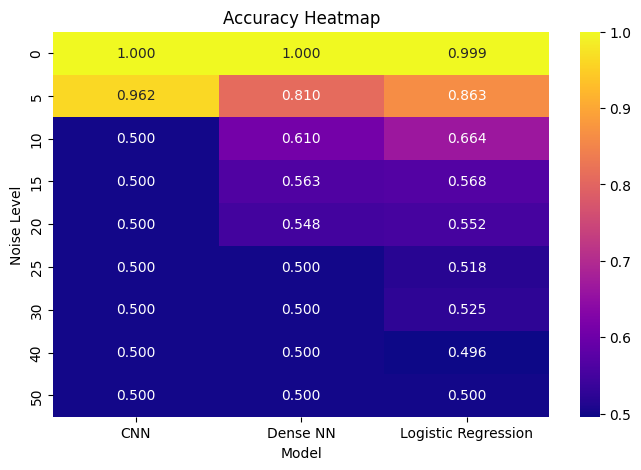

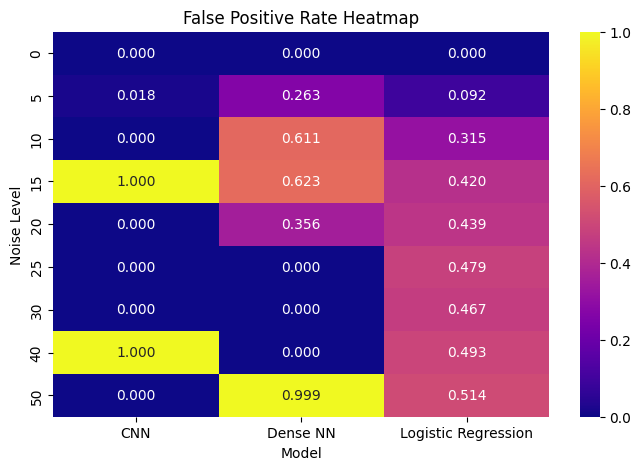

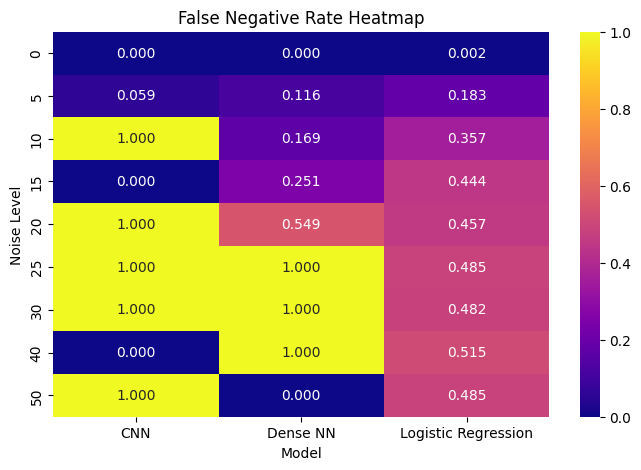

In [21]:
import seaborn as sns
import pandas as pd

pivot_acc = results_df.pivot(index="Noise Level", columns="Model", values="Accuracy")

plt.figure(figsize=(8,5))
sns.heatmap(pivot_acc, annot=True, fmt=".3f", cmap="plasma")
plt.title("Accuracy Heatmap")
plt.show()

pivot_fpr = results_df.pivot(index="Noise Level", columns="Model", values="False Positive Rate")
pivot_fnr = results_df.pivot(index="Noise Level", columns="Model", values="False Negative Rate")

plt.figure(figsize=(8,5))
sns.heatmap(pivot_fpr, annot=True, fmt=".3f", cmap="plasma")
plt.title("False Positive Rate Heatmap")
plt.show()

plt.figure(figsize=(8,5))
sns.heatmap(pivot_fnr, annot=True, fmt=".3f", cmap="plasma")
plt.title("False Negative Rate Heatmap")
plt.show()

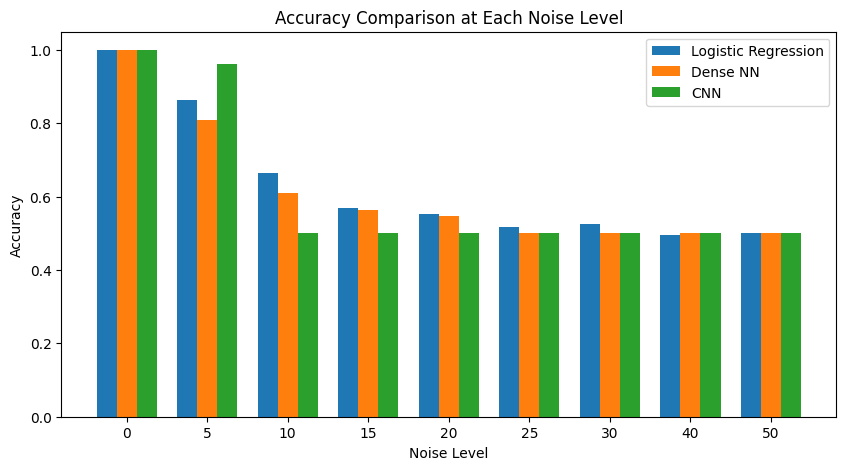

In [22]:
import numpy as np

noise_levels = sorted(results_df["Noise Level"].unique())
models = results_df["Model"].unique()

x = np.arange(len(noise_levels))
width = 0.25

plt.figure(figsize=(10,5))

for i, model in enumerate(models):
    subset = results_df[results_df["Model"] == model].sort_values("Noise Level")
    plt.bar(x + i*width, subset["Accuracy"], width=width, label=model)

plt.xticks(x + width, noise_levels)
plt.xlabel("Noise Level")
plt.ylabel("Accuracy")
plt.title("Accuracy Comparison at Each Noise Level")
plt.ylim(0, 1.05)
plt.legend()
plt.show()

## 6. Extensions

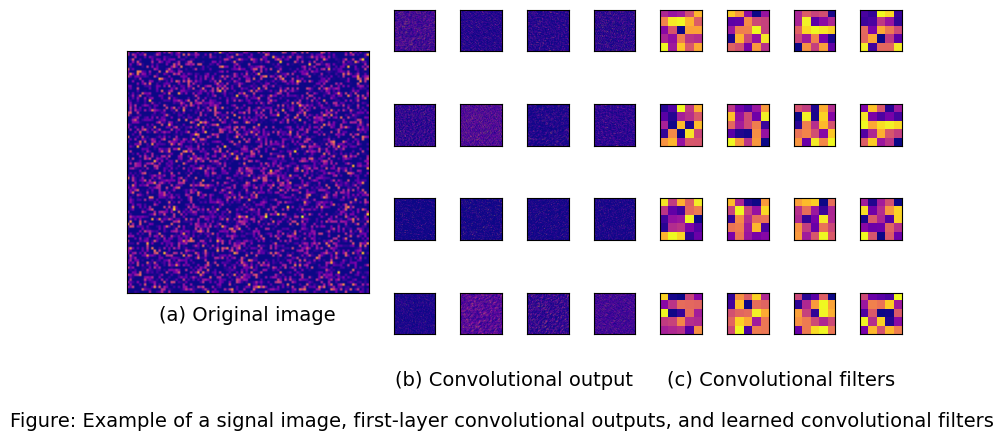

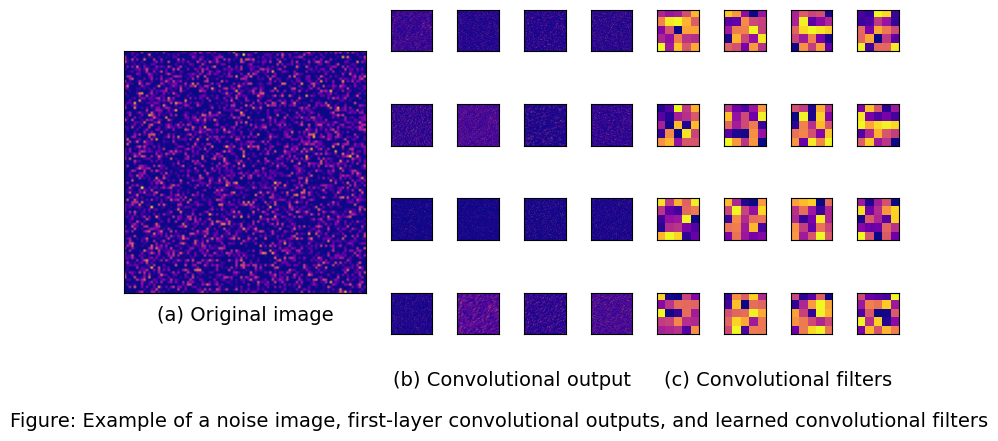

In [ ]:
from tensorflow.keras.models import Model
import matplotlib.pyplot as plt
import numpy as np

# choose one signal and one noise image
signal_indices = np.where(y_all == 1)[0]
signal_strength = X_all_cnn[signal_indices].sum(axis=(1,2,3))
signal_index = signal_indices[np.argmax(signal_strength)]

noise_indices = np.where(y_all == 0)[0]
noise_strength = X_all_cnn[noise_indices].sum(axis=(1,2,3))
noise_index = noise_indices[np.argmin(noise_strength)]

X_signal = X_all_cnn[signal_index:signal_index+1]
X_noise  = X_all_cnn[noise_index:noise_index+1]

#model for first conv-layer outputs
_ = model_cnn.predict(X_signal, verbose=0)

activation_model = Model(
    inputs=model_cnn.inputs,
    outputs=model_cnn.layers[0].output   # first Conv2D layer
)

signal_maps = activation_model.predict(X_signal, verbose=0)
noise_maps  = activation_model.predict(X_noise, verbose=0)

filters, _ = model_cnn.layers[0].get_weights()

# plotting function
def plot_cnn_visualisation(X_sample, feature_maps, filters, title_text):
    '''
    Plots a visualisation of CNN behaviour for a single input image.

    The figure includes:
    (a) the original input image,
    (b) the corresponding feature maps from the first convolutional layer,
    (c) the learned convolutional filters.

    Inputs
    - X_sample : input image array (expects shape [1, height, width, channels])
    - feature_maps : output feature maps from a convolutional layer
    - filters : convolutional filter weights from the model
    - title_text : string for the overall figure caption

    Outputs
    - None (displays a matplotlib figure)
    '''
    n_maps = min(16, feature_maps.shape[-1])
    n_filters = min(16, filters.shape[-1])

    fig = plt.figure(figsize=(10, 5))

    # original image
    ax1 = plt.subplot2grid((4, 12), (0, 0), rowspan=4, colspan=4)
    ax1.imshow(X_sample[0, :, :, 0], cmap="plasma")
    ax1.set_title("(a) Original image", fontsize=14, y=-0.15)
    ax1.set_xticks([])
    ax1.set_yticks([])

    # feature maps
    for i in range(n_maps):
        row = i // 4
        col = i % 4
        ax = plt.subplot2grid((4, 12), (row, 4 + col), colspan=1)
        ax.imshow(feature_maps[0, :, :, i], cmap="plasma")
        ax.set_xticks([])
        ax.set_yticks([])

    ax_mid_label = plt.subplot2grid((4, 12), (3, 4), colspan=4)
    ax_mid_label.axis("off")
    ax_mid_label.text(
        0.5, -0.35, "(b) Convolutional output",
        ha="center", va="top", fontsize=14, transform=ax_mid_label.transAxes
    )

    # filters
    for i in range(n_filters):
        row = i // 4
        col = i % 4
        ax = plt.subplot2grid((4, 12), (row, 8 + col), colspan=1)
        ax.imshow(filters[:, :, 0, i], cmap="plasma")
        ax.set_xticks([])
        ax.set_yticks([])

    ax_right_label = plt.subplot2grid((4, 12), (3, 8), colspan=4)
    ax_right_label.axis("off")
    ax_right_label.text(
        0.5, -0.35, "(c) Convolutional filters",
        ha="center", va="top", fontsize=14, transform=ax_right_label.transAxes
    )

    plt.subplots_adjust(wspace=0.6, hspace=0.4, bottom=0.18)
    plt.figtext(0.5, 0.02, title_text, ha="center", fontsize=14)
    plt.show()

# make one figure for signal
plot_cnn_visualisation(
    X_signal,
    signal_maps,
    filters,
    "Figure: Example of a signal image, first-layer convolutional outputs, and learned convolutional filters"
)

# make one figure for noise
plot_cnn_visualisation(
    X_noise,
    noise_maps,
    filters,
    "Figure: Example of a noise image, first-layer convolutional outputs, and learned convolutional filters"
)

## Extension 1: Inception CNN Model
The Inception CNN applies multiple convolutional filters of different sizes in parallel. This allows the model to analyse features at different spatial scales within the same layer. It is useful for neutrino images, which contain both small and larger structures. This can improve performance at intermediate noise levels. [[8]](#ref8)

In [ ]:
# Simple Inception block
# This lets the network look at the same image using different filter sizes at once
def inception_block(x, f1, f3, f5, fpool):
    '''
    Defines an Inception block with multiple convolutional branches.

    The block applies parallel convolutions of different kernel sizes
    to capture features at multiple spatial scales, followed by concatenation.

    Inputs
    - x : input tensor
    - f1 : number of filters for 1x1 convolution branch
    - f3 : number of filters for 3x3 convolution branch
    - f5 : number of filters for 5x5 convolution branch
    - fpool : number of filters for pooling branch (after 1x1 convolution)

    Outputs
    - output tensor formed by concatenating all branches
    '''

    # 1x1 branch for very local features
    branch1 = layers.Conv2D(f1, (1, 1), activation="relu", padding="same")(x)

    # 3x3 branch for medium-sized features
    branch2 = layers.Conv2D(f3, (3, 3), activation="relu", padding="same")(x)

    # 5x5 branch for larger features
    branch3 = layers.Conv2D(f5, (5, 5), activation="relu", padding="same")(x)

    # max-pooling branch to keep strong features
    branch4 = layers.MaxPooling2D((3, 3), strides=(1, 1), padding="same")(x)
    branch4 = layers.Conv2D(fpool, (1, 1), activation="relu", padding="same")(branch4)

    # join all branches together
    output = layers.concatenate([branch1, branch2, branch3, branch4])

    return output





def train_inception_cnn(X_all_cnn, y_all_cnn, show_plots=False):
    '''
    Trains an Inception-style CNN for binary image classification.

    The model combines standard convolutional layers with an Inception block
    to capture multi-scale spatial features, followed by dense layers for classification.

    Inputs
    - X_all_cnn : array of input images (shape [N, 100, 100, 1])
    - y_all_cnn : array of binary labels
    - show_plots : boolean to display training diagnostics and evaluation plots

    Outputs
    - model_cnn : trained Keras model
    - acc : test accuracy
    - fpr : false positive rate
    - fnr : false negative rate
    - y_test_cnn : true test labels
    - y_pred_cnn : predicted test labels
    - history_cnn : training history object
    '''
    
    # Train / validation / test split
    X_train_cnn, X_temp_cnn, y_train_cnn, y_temp_cnn = train_test_split(
        X_all_cnn, y_all_cnn, test_size=0.3, random_state=42, stratify=y_all_cnn
    )

    X_val_cnn, X_test_cnn, y_val_cnn, y_test_cnn = train_test_split(
        X_temp_cnn, y_temp_cnn, test_size=0.5, random_state=42, stratify=y_temp_cnn
    )

    # Model input
    inputs = keras.Input(shape=(100, 100, 1))

    # First standard convolution layer
    x = layers.Conv2D(16, (5, 5), activation="relu")(inputs)
    x = layers.MaxPooling2D((2, 2))(x)

    # Inception block
    x = inception_block(x, f1=8, f3=8, f5=8, fpool=8)
    x = layers.MaxPooling2D((2, 2))(x)

    # Second convolution layer
    x = layers.Conv2D(32, (3, 3), activation="relu")(x)
    x = layers.MaxPooling2D((2, 2))(x)

    # Flatten and dense layers for classification
    x = layers.Flatten()(x)
    x = layers.Dense(64, activation="relu")(x)
    outputs = layers.Dense(1, activation="sigmoid")(x)

    # Build model
    model_cnn = Model(inputs=inputs, outputs=outputs)

    model_cnn.compile(
        optimizer="adam",
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    # Early stopping callback to prevent overfitting
    callback = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
    )  

    # Train model
    history_cnn = model_cnn.fit(
        X_train_cnn, y_train_cnn,
        epochs=10,
        validation_data=(X_val_cnn, y_val_cnn),
        verbose=0,
        callbacks=[callback]
    )

    # Predict test labels
    y_pred_cnn = (model_cnn.predict(X_test_cnn, verbose=0) > 0.5).astype(int).flatten()

    # Get accuracy, false positive rate, false negative rate
    acc, fpr, fnr = get_metrics(y_test_cnn, y_pred_cnn)

    if show_plots:
        plot_training_history(history_cnn, "Inception CNN")
        print("Inception CNN Training Accuracy:", get_accuracy_keras(model_cnn, X_train_cnn, y_train_cnn))
        print("Inception CNN Validation Accuracy:", get_accuracy_keras(model_cnn, X_val_cnn, y_val_cnn))
        print("Inception CNN Test Accuracy:", acc)

        plot_conf_matrix_keras(model_cnn, X_test_cnn, y_test_cnn, title="Inception CNN Confusion Matrix")
        plot_roc_curve_keras(model_cnn, X_test_cnn, y_test_cnn, title="Inception CNN ROC Curve")

    return model_cnn, acc, fpr, fnr, y_test_cnn, y_pred_cnn, history_cnn

In [28]:
noise_levels = [0, 5, 10, 15, 20, 25, 30, 40, 50]

results = []
saved_predictions = {}

for noise_level in noise_levels:
    print("Running noise level:", noise_level)

    # Clear the Keras backend
    tf.keras.backend.clear_session()
    
    # Build dataset for this noise level
    X_all, y_all = make_dataset_with_noise(images, noise_level)

    # Shapes for input for inseption CNN
    X_all_inception_cnn = X_all.reshape(X_all.shape[0], X_all.shape[1], X_all.shape[2], 1)        # Inception CNN


    # Train and evaluate for each noise level

    # Inception CNN
    model_inception_cnn, acc_inception_cnn, fpr_inception_cnn, fnr_inception_cnn, y_test_inception_cnn, y_pred_inception_cnn, history_inception_cnn = train_inception_cnn(X_all_inception_cnn, y_all, show_plots=False)
    results.append(["Inception CNN", noise_level, acc_inception_cnn, fpr_inception_cnn, fnr_inception_cnn])
    saved_predictions[("Inception CNN", noise_level)] = (y_test_inception_cnn, y_pred_inception_cnn)

results_df2 = pd.DataFrame(results, columns=["Model", "Noise Level", "Accuracy", "False Positive Rate", "False Negative Rate"])
# Round metrics to 3 decimal places for better readability

results_df2["Accuracy"] = results_df2["Accuracy"].round(3)
results_df2["False Positive Rate"] = results_df2["False Positive Rate"].round(3)
results_df2["False Negative Rate"] = results_df2["False Negative Rate"].round(3)

results_df2

Running noise level: 0
Running noise level: 5
Running noise level: 10
Running noise level: 15
Running noise level: 20
Running noise level: 25
Running noise level: 30
Running noise level: 40
Running noise level: 50


,Model,Noise Level,Accuracy,False Positive Rate,False Negative Rate
0,Inception CNN,0,1.000,0.000,0.000
1,Inception CNN,5,0.962,0.029,0.048
2,Inception CNN,10,0.751,0.198,0.301
3,Inception CNN,15,0.500,1.000,0.000
4,Inception CNN,20,0.500,0.000,1.000
5,Inception CNN,25,0.500,1.000,0.000
6,Inception CNN,30,0.500,0.000,1.000
7,Inception CNN,40,0.500,0.000,1.000
8,Inception CNN,50,0.502,0.994,0.003


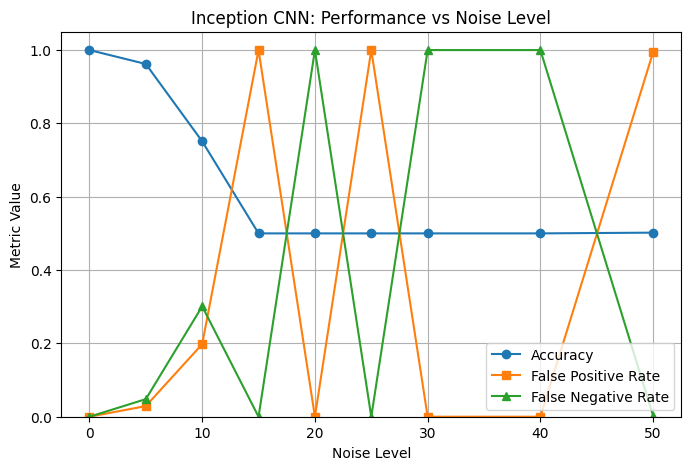

In [29]:
# Plot Inception CNN performance vs noise level
subset = results_df2[results_df2["Model"] == "Inception CNN"]

plt.figure(figsize=(8,5))
plt.plot(subset["Noise Level"], subset["Accuracy"], marker="o", label="Accuracy")
plt.plot(subset["Noise Level"], subset["False Positive Rate"], marker="s", label="False Positive Rate")
plt.plot(subset["Noise Level"], subset["False Negative Rate"], marker="^", label="False Negative Rate")

plt.xlabel("Noise Level")
plt.ylabel("Metric Value")
plt.title(f"Inception CNN: Performance vs Noise Level")
plt.ylim(0, 1.05)
plt.grid(True)
plt.legend()
plt.show()

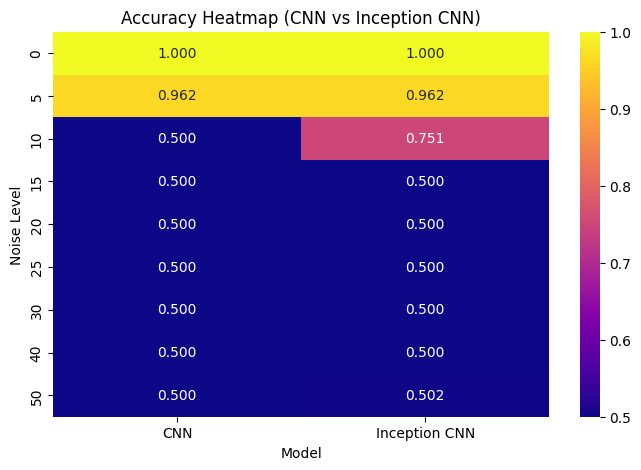

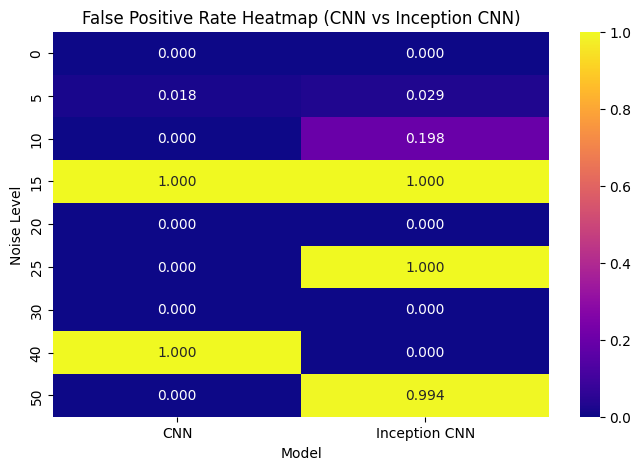

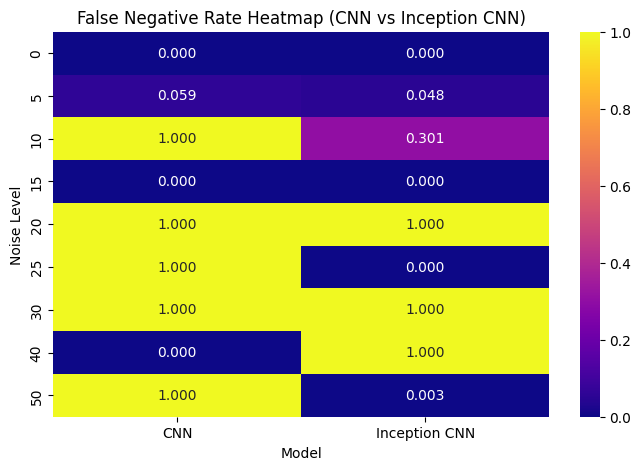

In [30]:


# Combine results
results_df_combined = pd.concat([results_df, results_df2], ignore_index=True)

# Filter only the two models you want
models_to_keep = ["CNN", "Inception CNN"]
filtered_df = results_df_combined[results_df_combined["Model"].isin(models_to_keep)]

# --- Accuracy Heatmap ---
pivot_acc = filtered_df.pivot(index="Noise Level", columns="Model", values="Accuracy")

plt.figure(figsize=(8,5))
sns.heatmap(pivot_acc, annot=True, fmt=".3f", cmap="plasma")
plt.title("Accuracy Heatmap (CNN vs Inception CNN)")
plt.show()

# --- False Positive Rate Heatmap ---
pivot_fpr = filtered_df.pivot(index="Noise Level", columns="Model", values="False Positive Rate")

plt.figure(figsize=(8,5))
sns.heatmap(pivot_fpr, annot=True, fmt=".3f", cmap="plasma")
plt.title("False Positive Rate Heatmap (CNN vs Inception CNN)")
plt.show()

# --- False Negative Rate Heatmap ---
pivot_fnr = filtered_df.pivot(index="Noise Level", columns="Model", values="False Negative Rate")

plt.figure(figsize=(8,5))
sns.heatmap(pivot_fnr, annot=True, fmt=".3f", cmap="plasma")
plt.title("False Negative Rate Heatmap (CNN vs Inception CNN)")
plt.show()

## Extension 2: Residual CNN Model

The residual CNN uses shortcut connections to pass information between layers. This helps preserve features and improves training stability in deeper networks. The model learns residual corrections rather than full mappings. However, for this task, the improvement over the baseline CNN is limited. [[9]](#ref9)

In [31]:
def simple_residual_block(x, filters):
    '''
    Defines a simple residual block for a CNN.

    The block applies two convolutional layers and adds the input (shortcut)
    to the output to preserve information and improve gradient flow.

    Inputs
    - x : input tensor
    - filters : number of convolutional filters

    Outputs
    - tensor after residual connection and activation
    '''
    shortcut = x

    x = layers.Conv2D(filters, (3, 3), padding="same", activation="relu")(x)
    x = layers.Conv2D(filters, (3, 3), padding="same", activation=None)(x)

    # make shortcut match if number of channels changes
    if shortcut.shape[-1] != filters:
        shortcut = layers.Conv2D(filters, (1, 1), padding="same", activation=None)(shortcut)

    x = layers.Add()([x, shortcut])
    x = layers.Activation("relu")(x)

    return x


def train_residual_cnn(X_all_res, y_all_res, show_plots=False):
    '''
    Trains a residual CNN for binary image classification.

    The model uses residual blocks to improve feature learning and stability,
    followed by dense layers for classification.

    Inputs
    - X_all_res : array of input images (shape [N, 100, 100, 1])
    - y_all_res : array of binary labels
    - show_plots : boolean to display training and evaluation plots

    Outputs
    - model_res : trained Keras model
    - acc_res : test accuracy
    - fpr_res : false positive rate
    - fnr_res : false negative rate
    - y_test_res : true test labels
    - y_pred_res : predicted test labels
    - history_res : training history object
    '''
    
    # Train / validation / test split
    X_train_res, X_temp_res, y_train_res, y_temp_res = train_test_split(
        X_all_res, y_all_res, test_size=0.3, random_state=42, stratify=y_all_res
    )

    X_val_res, X_test_res, y_val_res, y_test_res = train_test_split(
        X_temp_res, y_temp_res, test_size=0.5, random_state=42, stratify=y_temp_res
    )

    # Model
    inputs = keras.Input(shape=(100, 100, 1))

    x = layers.Conv2D(16, (3, 3), padding="same", activation="relu")(inputs)
    x = simple_residual_block(x, 16)
    x = layers.MaxPooling2D((2, 2))(x)

    x = layers.Conv2D(32, (3, 3), padding="same", activation="relu")(x)
    x = simple_residual_block(x, 32)
    x = layers.MaxPooling2D((2, 2))(x)

    x = layers.Flatten()(x)
    x = layers.Dense(64, activation="relu")(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(1, activation="sigmoid")(x)

    model_res = keras.Model(inputs, outputs)

    model_res.compile(
        optimizer="adam",
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )
    # Early stopping callback to prevent overfitting
    callback = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
    )   


    # Train
    history_res = model_res.fit(
        X_train_res, y_train_res,
        validation_data=(X_val_res, y_val_res),
        epochs=10,
        batch_size=32,
        verbose=0,
        callbacks=[callback]
    )

    # Predict
    y_prob_res = model_res.predict(X_test_res, verbose=0).ravel()
    y_pred_res = (y_prob_res > 0.5).astype(int)

    # Metrics
    acc_res, fpr_res, fnr_res = get_metrics(y_test_res, y_pred_res)

    if show_plots:
        plot_training_history(history_res, "Residual CNN")
        print("Residual CNN Training Accuracy:", get_accuracy_keras(model_res, X_train_res, y_train_res))
        print("Residual CNN Validation Accuracy:", get_accuracy_keras(model_res, X_val_res, y_val_res))
        print("Residual CNN Test Accuracy:", acc_res)

        plot_conf_matrix_keras(model_res, X_test_res, y_test_res, title="Residual CNN Confusion Matrix")
        plot_roc_curve_keras(model_res, X_test_res, y_test_res, title="Residual CNN ROC Curve")

    return model_res, acc_res, fpr_res, fnr_res, y_test_res, y_pred_res, history_res

In [32]:
noise_levels = [0, 5, 10, 15, 20, 25, 30, 40, 50]

results = []
saved_predictions = {}

for noise_level in noise_levels:
    print("Running noise level:", noise_level)

    # Clear the Keras backend
    tf.keras.backend.clear_session()

    # Build dataset for this noise level
    X_all, y_all = make_dataset_with_noise(images, noise_level)

    # reshape for Residual CNN input
    X_all_residual_cnn = X_all.reshape(X_all.shape[0], X_all.shape[1], X_all.shape[2], 1)

    # Residual CNN
    model_residual_cnn, acc_residual_cnn, fpr_residual_cnn, fnr_residual_cnn, y_test_residual_cnn, y_pred_residual_cnn, history_residual_cnn = train_residual_cnn(
        X_all_residual_cnn, y_all, show_plots=False
    )

    results.append([
        "Residual CNN",
        noise_level,
        acc_residual_cnn,
        fpr_residual_cnn,
        fnr_residual_cnn
    ])

    saved_predictions[("Residual CNN", noise_level)] = (y_test_residual_cnn, y_pred_residual_cnn)

results_df3 = pd.DataFrame(results, columns=["Model", "Noise Level", "Accuracy", "False Positive Rate", "False Negative Rate"])

# Round metrics to 3 decimal places for better readability
results_df3["Accuracy"] = results_df3["Accuracy"].round(3)
results_df3["False Positive Rate"] = results_df3["False Positive Rate"].round(3)
results_df3["False Negative Rate"] = results_df3["False Negative Rate"].round(3)


results_df3

Running noise level: 0
Running noise level: 5
Running noise level: 10
Running noise level: 15
Running noise level: 20
Running noise level: 25
Running noise level: 30
Running noise level: 40
Running noise level: 50


,Model,Noise Level,Accuracy,False Positive Rate,False Negative Rate
0,Residual CNN,0,1.000,0.000,0.000
1,Residual CNN,5,0.962,0.029,0.047
2,Residual CNN,10,0.500,0.000,1.000
3,Residual CNN,15,0.500,0.000,1.000
4,Residual CNN,20,0.500,0.000,1.000
5,Residual CNN,25,0.500,1.000,0.000
6,Residual CNN,30,0.500,0.000,1.000
7,Residual CNN,40,0.500,0.000,1.000
8,Residual CNN,50,0.500,0.000,1.000


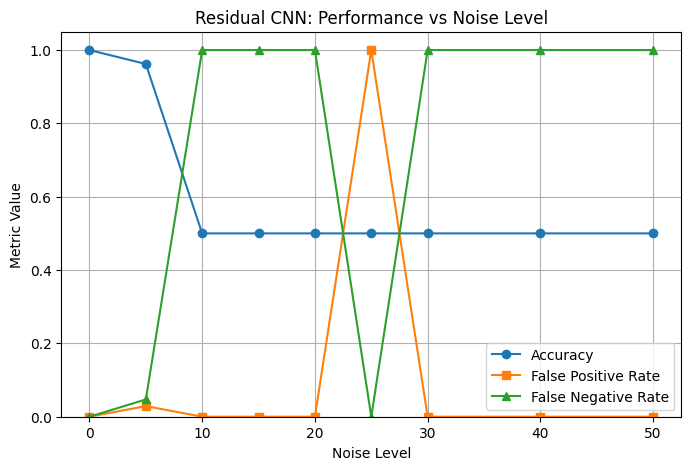

In [33]:
subset = results_df3[results_df3["Model"] == "Residual CNN"]

plt.figure(figsize=(8,5))
plt.plot(subset["Noise Level"], subset["Accuracy"], marker="o", label="Accuracy")
plt.plot(subset["Noise Level"], subset["False Positive Rate"], marker="s", label="False Positive Rate")
plt.plot(subset["Noise Level"], subset["False Negative Rate"], marker="^", label="False Negative Rate")

plt.xlabel("Noise Level")
plt.ylabel("Metric Value")
plt.title("Residual CNN: Performance vs Noise Level")
plt.ylim(0, 1.05)
plt.grid(True)
plt.legend()
plt.show()

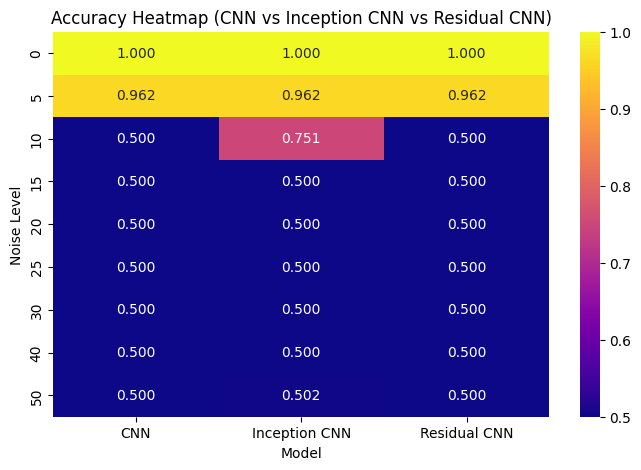

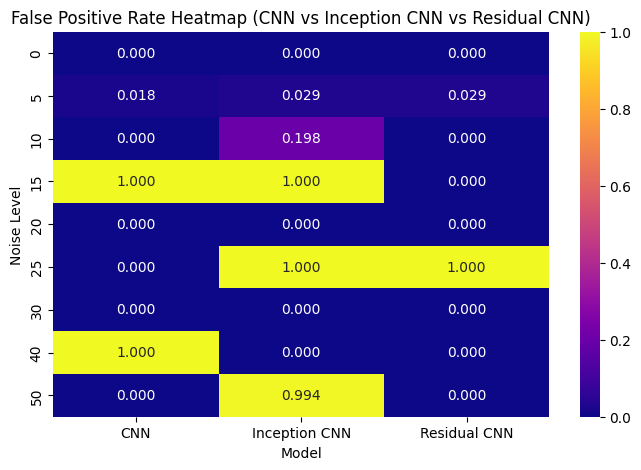

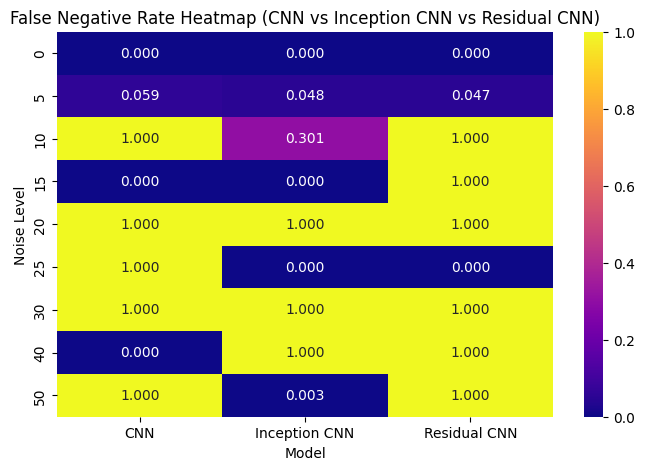

In [34]:
# Combine results
results_df_combined = pd.concat([results_df, results_df2,results_df3], ignore_index=True)

# Filter only the two models you want
models_to_keep = ["CNN", "Inception CNN", "Residual CNN"]
filtered_df = results_df_combined[results_df_combined["Model"].isin(models_to_keep)]

# --- Accuracy Heatmap ---
pivot_acc = filtered_df.pivot(index="Noise Level", columns="Model", values="Accuracy")

plt.figure(figsize=(8,5))
sns.heatmap(pivot_acc, annot=True, fmt=".3f", cmap="plasma")
plt.title("Accuracy Heatmap (CNN vs Inception CNN vs Residual CNN)")
plt.show()

# --- False Positive Rate Heatmap ---
pivot_fpr = filtered_df.pivot(index="Noise Level", columns="Model", values="False Positive Rate")

plt.figure(figsize=(8,5))
sns.heatmap(pivot_fpr, annot=True, fmt=".3f", cmap="plasma")
plt.title("False Positive Rate Heatmap (CNN vs Inception CNN vs Residual CNN)")
plt.show()

# --- False Negative Rate Heatmap ---
pivot_fnr = filtered_df.pivot(index="Noise Level", columns="Model", values="False Negative Rate")

plt.figure(figsize=(8,5))
sns.heatmap(pivot_fnr, annot=True, fmt=".3f", cmap="plasma")
plt.title("False Negative Rate Heatmap (CNN vs Inception CNN vs Residual CNN)")
plt.show()

## Extension 3: Simulating Radioactive Gaussian Blobs

In [35]:
def generate_gaussian_blob(shape, x0, y0, sigma, height):
    '''
    Generates a single 2D Gaussian blob image

    Inputs
    - shape  - tuple giving image shape
    - x0     - x centre of blob
    - y0     - y centre of blob
    - sigma  - width of blob
    - height - peak intensity of blob

    Outputs
    - image  - 2D array with Gaussian blob
    '''
    yy, xx = np.mgrid[0:shape[0], 0:shape[1]]

    image = height * np.exp(
        -((xx - x0)**2 + (yy - y0)**2) / (2 * sigma**2)
    )

    return image.astype("float32")


def generate_radioactive_event(sigma, height, image_shape=(100, 100), rng=None):
    '''
    Generates one radioactive-noise image containing a Gaussian blob

    Inputs
    - sigma       - Gaussian width
    - height      - Gaussian peak intensity
    - image_shape - shape of image
    - rng         - numpy random generator

    Outputs
    - image       - array of shape image_shape
    '''
    if rng is None:
        rng = np.random.default_rng()

    # keep centre away from edges so blob is not badly truncated
    margin = max(3 * sigma, 1)
    x = rng.uniform(margin, image_shape[1] - 1 - margin)
    y = rng.uniform(margin, image_shape[0] - 1 - margin)

    image = generate_gaussian_blob(image_shape, x, y, sigma, height)

    return image


def radioactivearraymaker(num, sigma, height, image_shape=(100, 100), seed=42):
    '''
    Generates an array of radioactive blob images

    Inputs
    - num         - number of images
    - sigma       - Gaussian width
    - height      - Gaussian peak intensity
    - image_shape - image shape
    - seed        - random seed

    Outputs
    - justnoise   - array of shape (num, image_shape[0], image_shape[1])
    '''
    rng = np.random.default_rng(seed)
    justnoise = np.zeros((num, image_shape[0], image_shape[1]), dtype="float32")

    for i in range(num):
        justnoise[i] = generate_radioactive_event(
            sigma=sigma,
            height=height,
            image_shape=image_shape,
            rng=rng
        )

    return justnoise

In [36]:
# Example usage
num_events = 9
sigma = 3
height = 5

testarray = radioactivearraymaker(num_events, sigma, height)
print(testarray.shape)

(9, 100, 100)


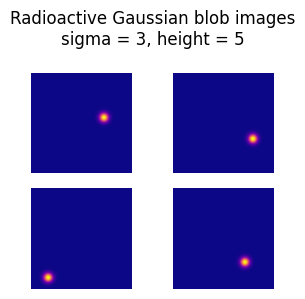

In [57]:
# Display 9 radioactive blob images
fig, axs = plt.subplots(2, 2, figsize=(3, 3))
fig.suptitle(f'Radioactive Gaussian blob images\nsigma = {sigma}, height = {height}')

for ax, image in zip(axs.flat, testarray):
    ax.imshow(image)
    ax.axis('off')

plt.tight_layout()
plt.show()

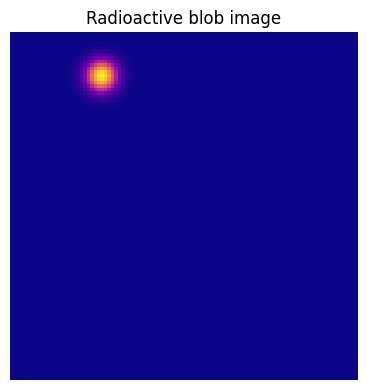

In [38]:
# Display one radioactive blob image
event = generate_radioactive_event(sigma=3, height=5)

plt.figure(figsize=(4, 4))
plt.imshow(event)
plt.title('Radioactive blob image')
plt.axis('off')
plt.tight_layout()
plt.show()

### overlay blob onto real neutrino images

In [43]:
def overlay_radioactive_blob(signal_images, sigma, height):
    '''
    Adds one radioactive Gaussian blob to each real neutrino image

    Inputs
    - signal_images - array of real neutrino images
    - sigma         - Gaussian width
    - height        - Gaussian peak intensity

    Outputs
    - noisy_signal_images - neutrino images with blob added
    '''

    
    # create dataset of blobs and add to signal images
    signal_images = signal_images.astype("float32")
    noisy_signal_images = np.zeros_like(signal_images, dtype="float32")
    image_shape = signal_images.shape[1:]
    rng = np.random.default_rng(42)

    # add one blob to each signal image
    for i in range(len(signal_images)):
        blob = generate_radioactive_event(
            sigma=sigma,
            height=height,
            image_shape=image_shape,
            rng=rng
        )
        noisy_signal_images[i] = signal_images[i] + blob

    # clip to original detector-like scale
    max_signal = signal_images.max()
    noisy_signal_images = np.clip(noisy_signal_images, 0.0, max_signal)

    return noisy_signal_images


def make_overlay_vs_radioactive_dataset(signal_images, sigma, height):
    '''
    Creates a binary classification dataset:
    1 = neutrino image with radioactive blob added
    0 = radioactive blob only image
    '''

    # prepare signal images with blob added
    signal_images = signal_images.astype("float32").copy()
    num_signal = len(signal_images)
    image_shape = signal_images.shape[1:]

    signal_with_blob = overlay_radioactive_blob(signal_images, sigma, height)

    # prepare background images of just blobs
    background_images = radioactivearraymaker(
        num=num_signal,
        sigma=sigma,
        height=height,
        image_shape=image_shape,
        seed=123
    )

    # prepare labels
    y_signal = np.ones(num_signal, dtype=int)
    y_background = np.zeros(num_signal, dtype=int)

    # combine and shuffle
    X_all = np.concatenate([signal_with_blob, background_images], axis=0).astype("float32")
    y_all = np.concatenate([y_signal, y_background], axis=0)

    # fixed normalisation scale (same as original signal images)
    scale = signal_images.max()
    if scale > 0:
        X_all = X_all / scale
    X_all = np.clip(X_all, 0.0, 1.0)

    # shuffle the dataset
    indices = np.random.permutation(len(X_all))
    X_all = X_all[indices]
    y_all = y_all[indices]

    return X_all, y_all

In [44]:
def run_overlay_grid_inception(signal_images, sigma_values, height_values):
    '''
    Tests Inception CNN for:
    neutrino + radioactive blob  vs  radioactive blob only

    Inputs
    - signal_images - array of real neutrino images
    - sigma_values  - list of Gaussian widths to test
    - height_values - list of Gaussian heights to test

    Outputs
    - results_df_overlay - dataframe of results
    '''
    results = []

    # loop over grid of sigma and height values to test
    for sigma in sigma_values:
        for height in height_values:
            print(f'Running sigma = {sigma}, height = {height}')

            # Build dataset
            X_all, y_all = make_overlay_vs_radioactive_dataset(
                signal_images, sigma, height
            )

            # Reshape for Inception CNN
            X_all_inception_cnn = X_all.reshape(
                X_all.shape[0], X_all.shape[1], X_all.shape[2], 1
            )

            # Train and test model
            model_inception_cnn, acc_inception_cnn, fpr_inception_cnn, fnr_inception_cnn, y_test_inception_cnn, y_pred_inception_cnn, history_inception_cnn = train_inception_cnn(
                X_all_inception_cnn, y_all, show_plots=False
            )

            results.append([
                sigma,
                height,
                acc_inception_cnn,
                fpr_inception_cnn,
                fnr_inception_cnn
            ])

    results_df_overlay = pd.DataFrame(
        results,
        columns=['Sigma', 'Height', 'Accuracy', 'False Positive Rate', 'False Negative Rate']
    )

    return results_df_overlay

def plot_overlay_heatmaps(results_df_overlay):
    '''
    Plots heatmaps for accuracy, false positive rate, and false negative rate
    '''

    # create pivot tables for heatmaps
    pivot_acc = results_df_overlay.pivot(index='Sigma', columns='Height', values='Accuracy')
    pivot_fpr = results_df_overlay.pivot(index='Sigma', columns='Height', values='False Positive Rate')
    pivot_fnr = results_df_overlay.pivot(index='Sigma', columns='Height', values='False Negative Rate')

    # plot heatmaps
    fig, axs = plt.subplots(1, 3, figsize=(18, 5))

    im1 = axs[0].imshow(pivot_acc, aspect='auto', origin='lower')
    axs[0].set_title('Accuracy')
    axs[0].set_xlabel('Height')
    axs[0].set_ylabel('Sigma')
    axs[0].set_xticks(range(len(pivot_acc.columns)))
    axs[0].set_xticklabels(pivot_acc.columns)
    axs[0].set_yticks(range(len(pivot_acc.index)))
    axs[0].set_yticklabels(pivot_acc.index)
    plt.colorbar(im1, ax=axs[0])

    im2 = axs[1].imshow(pivot_fpr, aspect='auto', origin='lower')
    axs[1].set_title('False Positive Rate')
    axs[1].set_xlabel('Height')
    axs[1].set_ylabel('Sigma')
    axs[1].set_xticks(range(len(pivot_fpr.columns)))
    axs[1].set_xticklabels(pivot_fpr.columns)
    axs[1].set_yticks(range(len(pivot_fpr.index)))
    axs[1].set_yticklabels(pivot_fpr.index)
    plt.colorbar(im2, ax=axs[1])

    im3 = axs[2].imshow(pivot_fnr, aspect='auto', origin='lower')
    axs[2].set_title('False Negative Rate')
    axs[2].set_xlabel('Height')
    axs[2].set_ylabel('Sigma')
    axs[2].set_xticks(range(len(pivot_fnr.columns)))
    axs[2].set_xticklabels(pivot_fnr.columns)
    axs[2].set_yticks(range(len(pivot_fnr.index)))
    axs[2].set_yticklabels(pivot_fnr.index)
    plt.colorbar(im3, ax=axs[2])

    plt.tight_layout()
    plt.show()

Running sigma = 1, height = 1
Running sigma = 1, height = 3
Running sigma = 1, height = 5
Running sigma = 3, height = 1
Running sigma = 3, height = 3
Running sigma = 3, height = 5
Running sigma = 5, height = 1
Running sigma = 5, height = 3
Running sigma = 5, height = 5
   Sigma  Height  Accuracy  False Positive Rate  False Negative Rate
0      1       1  1.000000                  0.0             0.000000
1      1       3  1.000000                  0.0             0.000000
2      1       5  1.000000                  0.0             0.000000
3      3       1  0.999333                  0.0             0.001333
4      3       3  0.999667                  0.0             0.000667
5      3       5  1.000000                  0.0             0.000000
6      5       1  1.000000                  0.0             0.000000
7      5       3  0.999667                  0.0             0.000667
8      5       5  1.000000                  0.0             0.000000


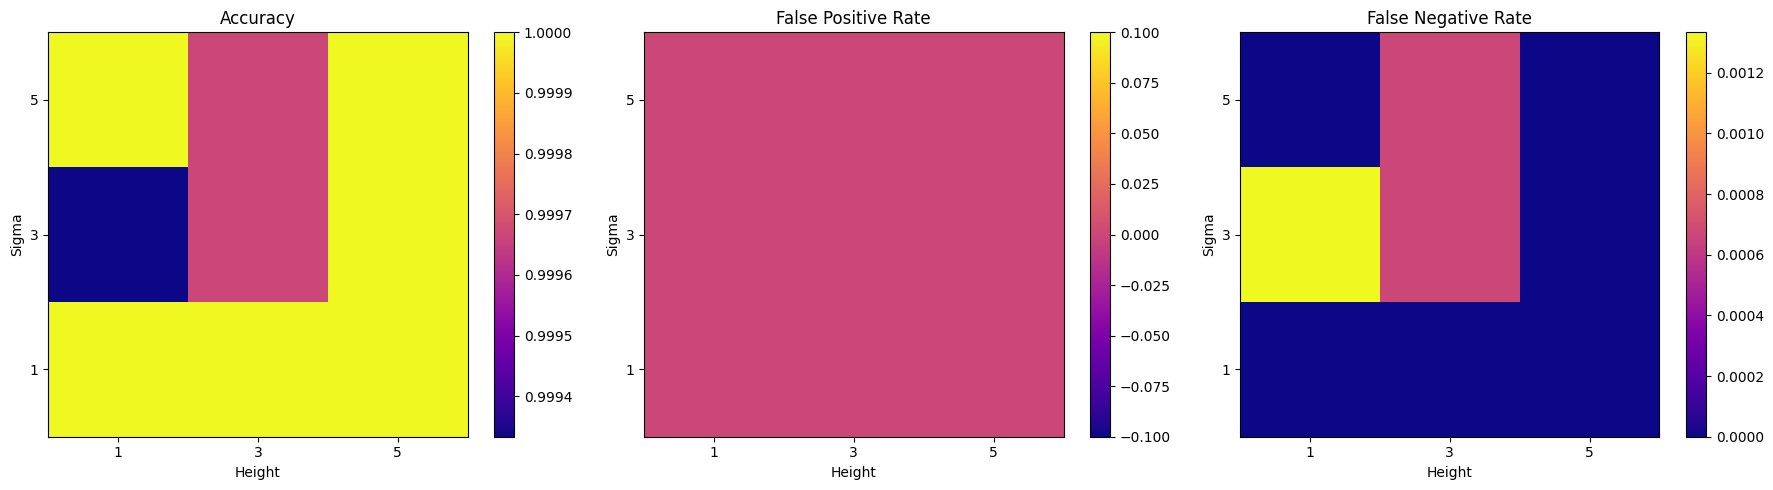

In [48]:
# Define grid of sigma and height values to test for overlay scenario
sigma_values = [1, 3, 5,]
height_values = [1, 3, 5]

# Run the grid search for the overlay scenario and plot results
results_df_overlay = run_overlay_grid_inception(
    signal_images=images,
    sigma_values=sigma_values,
    height_values=height_values
)

#  Display results
print(results_df_overlay)
plot_overlay_heatmaps(results_df_overlay)

## Overall Conclusion

All models perform very well at low noise, where the signal is clearly visible. Logistic regression and the dense network achieve near-perfect accuracy, but degrade steadily as noise increases. This is because they rely on global pixel values.
The CNN performs best at low noise, reaching an accuracy of around 0.96 at moderate noise levels. This shows that spatial features are important for identifying neutrino events. However, beyond a certain noise level, all models approach random guessing, with accuracy close to 0.5.
The Inception CNN provides a small improvement at intermediate noise, while the residual CNN shows no clear benefit. This suggests that changing the architecture does not remove the main limitation.
For Gaussian blob backgrounds, performance remains high across most cases. This is because the noise is localised and does not fully obscure the signal. Overall, performance is limited by the signal-to-noise ratio rather than the model design.

## References
<a id="ref1"></a>
[1]: MicroBooNE Detector -  R. Acciarri et al., “Design and Construction of the MicroBooNE Detector,” JINST, vol. 12, no. 02, P02017, 2017.

<a id="ref2"></a>
[2]: DUNE Experiment - B. Abi et al., “Deep Underground Neutrino Experiment (DUNE), Far Detector Technical Design Report,” JINST, vol. 15, no. 08, T08008, 2020.


<a id="ref3"></a>
[3]: SN1987A Neutrino Detection – K. Hirata et al., “Observation of a Neutrino Burst from the Supernova SN1987A,” hys. Rev. Lett., vol. 58, no. 14, pp. 1490–1493, 1987.

<a id="ref4"></a>
[4]: SNEWS Early Warning System – SNEWS Collaboration, “SuperNova Early Warning System,” https://snews.bnl.gov

<a id="ref5"></a>
[5]: Particle Data Group (PDG) – P. A. Zyla et al., “Review of Particle Physics,” Prog. Theor. Exp. Phys., 2020.

<a id="ref6"></a>
[6]: CNN Neutrino Classifier – A. Aurisano et al., “A Convolutional Neural Network Neutrino Event Classifier,” JINST, vol. 11, P09001, 2016.

<a id="ref7"></a>
[7]: Deep Learning (General) – Y. LeCun, Y. Bengio, and G. Hinton, “Deep Learning,” Nature, vol. 521, pp. 436–444, 2015.

<a id="ref8"></a>
[8]: Inception CNN – C. Szegedy et al., “Going Deeper with Convolutions,” in Proc. IEEE CVPR, 2015.

<a id="ref9"></a>
[9]: Residual CNN (ResNet) – K. He et al., “Deep Residual Learning for Image Recognition,” in Proc. IEEE CVPR, 2016.


